# AI-Powered Grievance Classification System — Bengaluru
### Automatically route citizen complaints to the correct civic authority and predict their urgency

---

**Project Overview**

Bengaluru receives thousands of citizen grievances daily across multiple civic agencies — BBMP, BWSSB, BESCOM, BTP, and others. Manually triaging these complaints is slow, error-prone, and costly.

This notebook builds an end-to-end NLP pipeline that:
1. **Routes complaints** to the correct civic authority (civic agency classification)
2. **Prioritises complaints** by predicted urgency: Low → Medium → High → Critical (severity classification)

Both tasks use the same complaint text as input. We benchmark classical ML models (Logistic Regression, LinearSVC, Random Forest, Multinomial Naive Bayes) against deep learning approaches (DistilBERT fine-tuning, BiLSTM).

---

**Notebook Structure**

| Section | Description |
|---------|-------------|
| 1 | Data Retrieval & Cleaning |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Civic Agency Classification — Preprocessing, Augmentation & Training |
| 4 | Civic Agency Classification — Final Dataset & Model Saving |
| 5 | Severity Classification — Preprocessing, Augmentation, Training & Inference |

---


## 1  Data Retrieval & Cleaning

### 1.1  Imports & Environment Setup

All standard libraries, ML frameworks, and NLP tools are loaded here.  
GPU memory is capped at 75 % to prevent OOM errors during augmentation and fine-tuning.


In [442]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import re, copy, json, glob, gzip, random, shutil, logging, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from pathlib import Path

# ── Data Manipulation & Visualisation ────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json
from tqdm.auto import tqdm
import requests
import time

# ── Environment & Database ───────────────────────────────────────────────────
from dotenv import load_dotenv
from sqlalchemy import create_engine

# ── NLP Tools ────────────────────────────────────────────────────────────────
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import nlpaug.augmenter.sentence as nas

# Prevent accidental downloads inside a controlled environment
nltk.download = lambda *args, **kwargs: True

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import StratifiedKFold, ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, precision_recall_fscore_support,
    classification_report, precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_class_weight

# ── PyTorch & Hugging Face ────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.75, device=0)
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy.special import softmax
from scipy.stats import ttest_ind, mannwhitneyu

# -- Open AI API --------------------------------------------------------------
from openai import OpenAI
import google.generativeai as genai

# ── Project Root ─────────────────────────────────────────────────────────────
# Assumes this notebook lives one level inside the project (e.g. /notebook/)
PROJECT_ROOT = Path.cwd().parent
CHARTS_DIR   = PROJECT_ROOT / "charts_and_graphs"
CHARTS_DIR.mkdir(exist_ok=True)
print(f"Project root : {PROJECT_ROOT}")
print(f"Charts folder: {CHARTS_DIR}")


Project root : c:\Users\sandi\Desktop\ML Working Folder\ai_grievance_system
Charts folder: c:\Users\sandi\Desktop\ML Working Folder\ai_grievance_system\charts_and_graphs


### 1.2  Database Connection

Credentials are stored in a `.env` file at `<project_root>/src/.env` — **never hard-coded**.


In [443]:
load_dotenv(dotenv_path=PROJECT_ROOT / "src" / ".env", override=True)

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('user')}:{os.getenv('password')}"
    f"@{os.getenv('host')}:{os.getenv('port')}/{os.getenv('dbname')}?sslmode=require"
)

engine = create_engine(DATABASE_URL)

try:
    with engine.connect() as conn:
        print("✅ Database connection successful.")
except Exception as e:
    print(f"❌ Connection failed: {e}")


✅ Database connection successful.


### 1.3  Load Full Dataset


In [444]:
df = pd.read_sql("SELECT * FROM public.bangalore_data;", engine)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (17150, 17)


,id,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,severity
0,11,2019-01-02 07:30:00,42,Cutting the very old trees by putting concentr...,"Dear Forest officer of BBMP,\n\nThis is to bri...",180,10.0,"Unnamed Road, Kaveri Nagar, Bengaluru, Karnata...","Vidhanasoudha layout , 6th Cross ,Sainik Publi...",13.016368,77.522351,Lakshmi Devi Nagar,473.0,Trees and Saplings,Defacement Of Trees,BBMP,High
1,12,2019-01-02 09:29:00,182,Sewage septic tank overflow,I raised complaint in bwssb site docket number...,72,2.0,"47/38, 20Th Main Rd, Anjanaswamy Layout, Padma...",NU hospital,12.917146,77.553969,Padmanabha Nagar,472.0,Sewerage Systems,Maintenance And Repair Of Sewage Lines,BWSSB,High
2,13,2019-01-02 12:52:00,192,Begur road one way needs repair. It's full of ...,Begur road one way needs repair. It's full of ...,66,10.0,"Begur, Bengaluru, Karnataka, India",NaN,12.878767,77.637668,Begur,15.0,"Mobility - Roads, Footpaths and Infrastructure",Fixing/Reparing Potholes,BBMP,Medium
3,14,2019-01-02 13:54:00,26,Big Potholes due to sewage water,"Dear Sir / Mam,\n\nThis is to bring to your ki...",66,10.0,"Kanakanagara Main Rd, Nri Layout, Bengaluru, K...",Opp. to Water Tank,13.038787,77.681254,Ramamurthy Nagar,15.0,"Mobility - Roads, Footpaths and Infrastructure",Fixing/Reparing Potholes,BBMP,Medium
4,15,2019-01-02 14:00:00,26,No proper road side drains,"Dear Sir / Mam,\n\nThis is to bring to your ki...",66,10.0,"2, K Channasandra Main Rd, K Channasandra, Ben...",Adjacent to Kattaramma temple,13.040147,77.680098,Ramamurthy Nagar,15.0,"Mobility - Roads, Footpaths and Infrastructure",Fixing/Reparing Potholes,BBMP,Medium


### 1.4  Missing-Value Analysis

We check the percentage of nulls across all columns before deciding which rows to drop.


In [445]:
df_null_pct = df.isna().mean() * 100
print("Null percentage per column (non-zero only):")
print(df_null_pct[df_null_pct > 0].sort_values(ascending=False))


Null percentage per column (non-zero only):
address               44.163265
civic_agency_title     3.819242
civic_agency_id        3.609329
ward_title             0.186589
category_id            0.186589
category_title         0.186589
sub_category_title     0.104956
dtype: float64


### 1.5  Drop Null Records

Both `description` (the complaint text) and `severity` (the target label) are mandatory.
Any row missing either field is removed.


In [446]:
print(f"Rows before cleaning : {df.shape[0]:,}")
df.dropna(subset=["description", "civic_agency_title", "severity"], inplace=True)
print(f"Rows after dropping nulls : {df.shape[0]:,}")

Rows before cleaning : 17,150
Rows after dropping nulls : 16,495


### 1.6  Standardise Civic Agency Names

Some agencies appear under both their full name and acronym (e.g. *BBMP* and *Bruhat Bengaluru Mahanagara Palike*), causing artificially split complaint counts.  
We consolidate all variants into a single canonical acronym, and merge very sparse agencies into the closest parent to reduce label sparsity.


In [447]:
# ── Step 1: full name → acronym ───────────────────────────────────────────────
agency_alias_map = {
    "Bruhat Bengaluru Mahanagara Palike":       "BBMP",
    "Bangalore Traffic Police":                 "BTP",
    "Bangalore Water Supply And Sewerage Board": "BWSSB",
    "Karnataka State Pollution Control Board":  "KSPCB",
    "Bangalore Electricity Supply Company":     "BESCOM",
}
df["civic_agency_title"] = df["civic_agency_title"].replace(agency_alias_map)

# ── Step 2: merge sparse agencies into parent categories ─────────────────────
agency_consolidation_map = {
    "BDA":   "BBMP",       # urban infrastructure overlap
    "BMTC":  "Transport",  # public transport
    "KSRTC": "Transport",
}
df["civic_agency_title"] = df["civic_agency_title"].replace(agency_consolidation_map)

print(f"Unique civic agencies after consolidation: {df['civic_agency_title'].nunique()}")
print(df["civic_agency_title"].value_counts())


Unique civic agencies after consolidation: 8
civic_agency_title
BBMP         12929
BWSSB         1083
BTP           1080
KSPCB          539
BCP            330
BESCOM         327
Transport      106
KSFES          101
Name: count, dtype: int64


### 1.7  Final Deduplication & Index Reset


In [448]:
df = (
    df.dropna(subset=["description", "severity"])
      .drop_duplicates()
      .reset_index(drop=True)
)
print(f"Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(2)


Final dataset: 16,495 rows × 17 columns


,id,created_at,ward_id,title,description,sub_category_id,civic_agency_id,location,address,latitude,longitude,ward_title,category_id,category_title,sub_category_title,civic_agency_title,severity
0,11,2019-01-02 07:30:00,42,Cutting the very old trees by putting concentr...,"Dear Forest officer of BBMP,\n\nThis is to bri...",180,10.0,"Unnamed Road, Kaveri Nagar, Bengaluru, Karnata...","Vidhanasoudha layout , 6th Cross ,Sainik Publi...",13.016368,77.522351,Lakshmi Devi Nagar,473.0,Trees and Saplings,Defacement Of Trees,BBMP,High
1,12,2019-01-02 09:29:00,182,Sewage septic tank overflow,I raised complaint in bwssb site docket number...,72,2.0,"47/38, 20Th Main Rd, Anjanaswamy Layout, Padma...",NU hospital,12.917146,77.553969,Padmanabha Nagar,472.0,Sewerage Systems,Maintenance And Repair Of Sewage Lines,BWSSB,High


---
## 2  Exploratory Data Analysis (EDA)

### 2.1  Complaint Length Distribution

We measure the word count of each complaint and examine how it varies across severity categories.  
Very short complaints (fewer than ~14 words) may lack enough context to reliably predict severity — this informs our augmentation threshold.


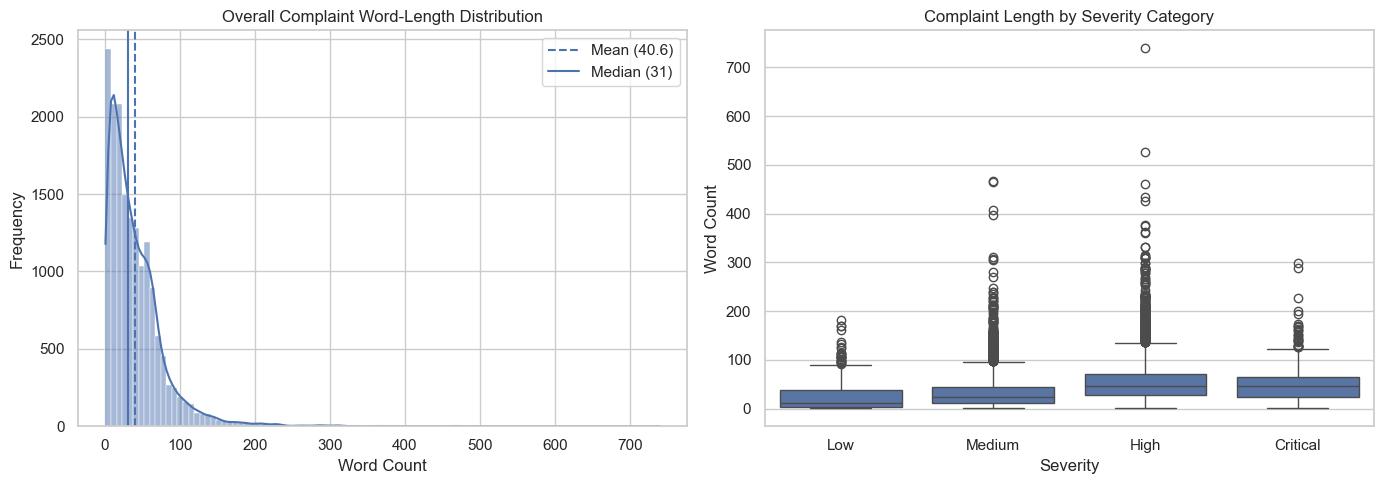

In [449]:
# Sort chronologically for time-based analysis later
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df = df.sort_values("created_at", ascending=True).reset_index(drop=True)

# Word-count feature
df["complaint_length"] = df["description"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.histplot(df["complaint_length"], bins=100, kde=True, ax=axes[0])
axes[0].axvline(df["complaint_length"].mean(),   linestyle="--",
                label=f'Mean ({df["complaint_length"].mean():.1f})')
axes[0].axvline(df["complaint_length"].median(), linestyle="-",
                label=f'Median ({df["complaint_length"].median():.0f})')
axes[0].set_title("Overall Complaint Word-Length Distribution")
axes[0].set_xlabel("Word Count"); axes[0].set_ylabel("Frequency")
axes[0].legend()

# By severity
sns.boxplot(x="severity", y="complaint_length", data=df,
            order=["Low", "Medium", "High", "Critical"], ax=axes[1])
axes[1].set_title("Complaint Length by Severity Category")
axes[1].set_xlabel("Severity"); axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig(CHARTS_DIR / "2.1_complaint_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Complaint length statistics by severity:

           count   mean    std  min   25%   50%   75%    max
severity                                                    
Critical   674.0  50.09  36.14  2.0  24.0  46.0  64.0  298.0
High      5658.0  56.62  45.22  1.0  28.0  47.0  71.0  739.0
Low       1028.0  24.32  26.71  1.0   4.0  12.0  38.0  181.0
Medium    9135.0  31.86  30.57  1.0  11.0  23.0  45.0  468.0


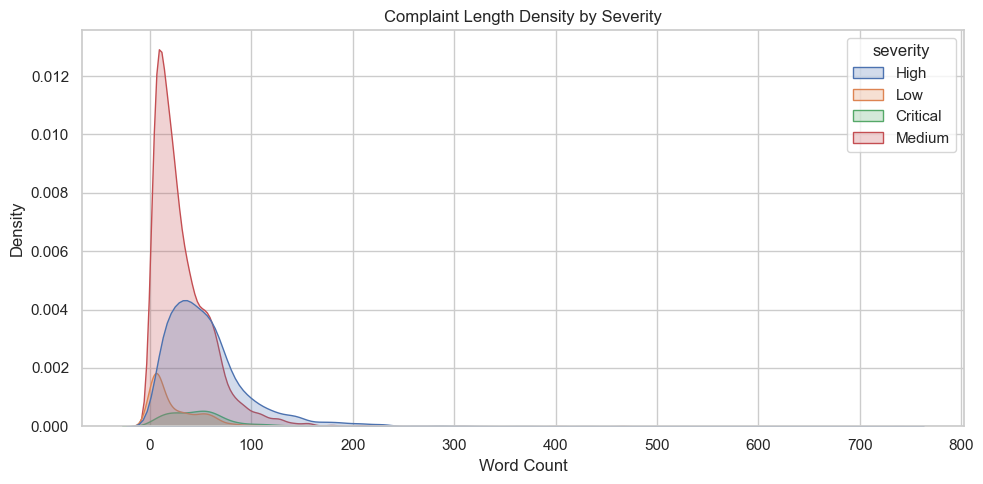

In [450]:
# Descriptive statistics per severity
print("Complaint length statistics by severity:\n")
print(df.groupby("severity")["complaint_length"].describe().round(2))

# KDE overlay
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="complaint_length", hue="severity", fill=True)
plt.title("Complaint Length Density by Severity")
plt.xlabel("Word Count")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "2.1b_complaint_length_kde.png", dpi=150, bbox_inches="tight")
plt.show()


In [451]:
# Percentile breakdown — useful for choosing the 256-word summarisation threshold
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_stats = (
    df.groupby("severity")["complaint_length"]
      .quantile(percentiles)
      .unstack()
      .round(2)
)
pct_stats.columns = [f"{int(p*100)}%" for p in percentiles]
print("Complaint length percentiles by severity:\n")
print(pct_stats)


Complaint length percentiles by severity:

           1%     5%   10%   25%   50%   75%    90%     95%    99%
severity                                                          
Critical  3.0   7.65  12.0  24.0  46.0  64.0   90.7  116.35  170.0
High      6.0  10.00  15.0  28.0  47.0  71.0  106.0  139.00  226.0
Low       1.0   2.00   2.0   4.0  12.0  38.0   60.0   72.00  112.0
Medium    2.0   3.00   5.0  11.0  23.0  45.0   67.0   85.00  136.0


In [452]:
# Inspect the shortest complaints — these are candidates for augmentation
df_short = df[df["complaint_length"] < 14][["description", "complaint_length", "severity"]].head(10)
print("Sample complaints under 14 words:")
display(df_short)

Sample complaints under 14 words:


,description,complaint_length,severity
11,Begur road one way needs repair. It's full of ...,10,Medium
14,Footpath cover broken,3,Medium
17,Garbage not removed from road,5,Medium
21,No garbage collection in vittasandra Main road...,10,Medium
22,There is sevage water over flow,6,Medium
26,Very Very Bad Road and needs to be retarded ur...,13,Medium
30,Leaking pipeline,2,Medium
34,Garbage dump in my area please clear it.,8,Medium
36,Garbage dump,2,Medium
37,Garbage Dump,2,Medium


### 2.2  Grievance Volume Over Time

We look at how total complaints — broken down by severity — have changed year over year.


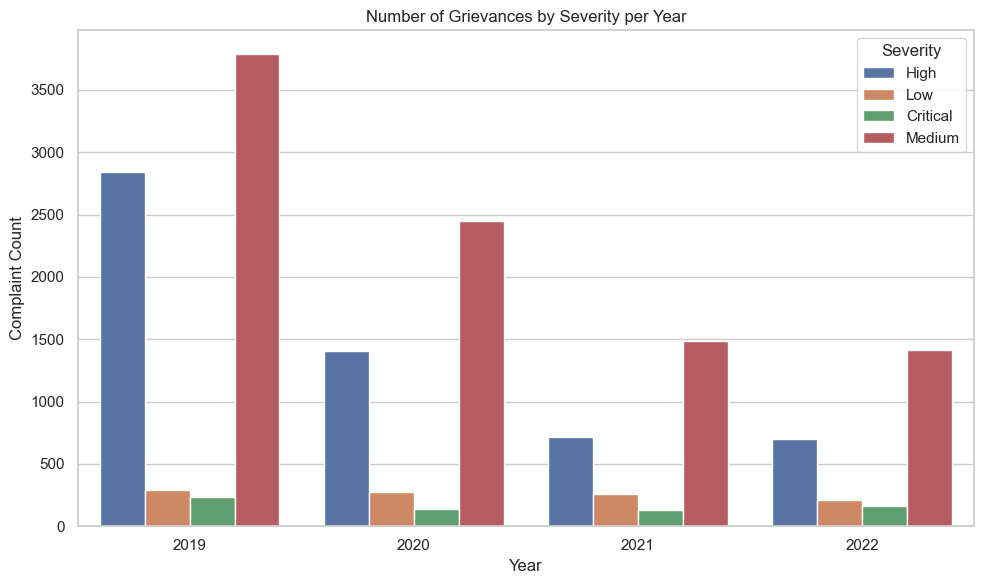

In [453]:
df["year"] = df["created_at"].dt.year

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="year", hue="severity")
plt.title("Number of Grievances by Severity per Year")
plt.xlabel("Year"); plt.ylabel("Complaint Count")
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "2.2_grievances_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3  Complaint Distribution per Civic Agency

Examining complaint volume across agencies, overall and by year, helps identify disproportionately burdened agencies and informs routing model complexity.


In [454]:
print(f"Total civic agencies (after consolidation): {df['civic_agency_title'].nunique()}")
print("\nComplaint count per agency:")
print(df["civic_agency_title"].value_counts())


Total civic agencies (after consolidation): 8

Complaint count per agency:
civic_agency_title
BBMP         12929
BWSSB         1083
BTP           1080
KSPCB          539
BCP            330
BESCOM         327
Transport      106
KSFES          101
Name: count, dtype: int64


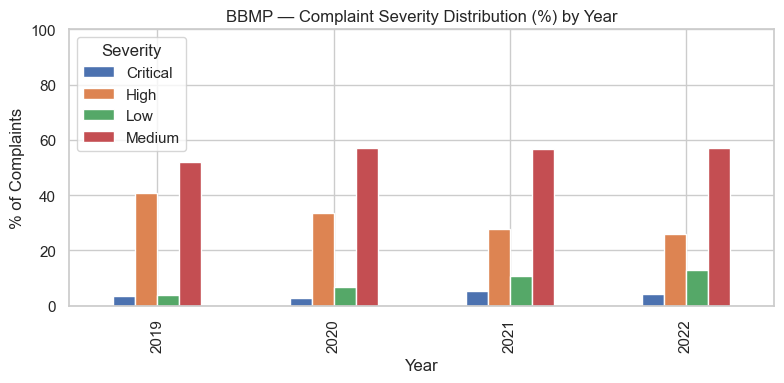

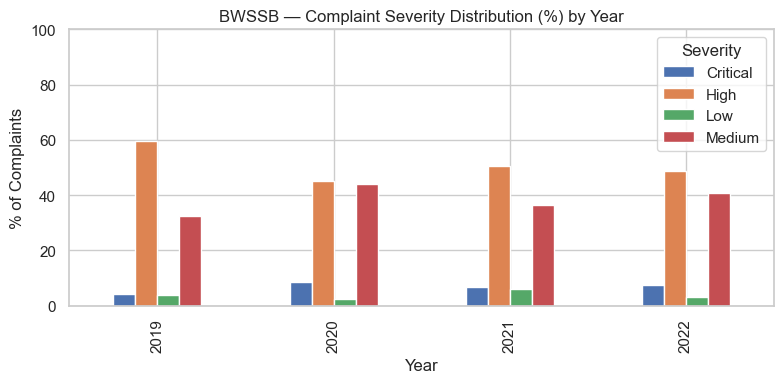

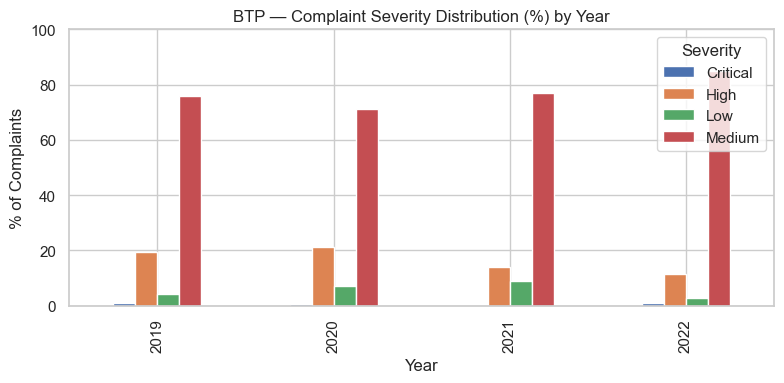

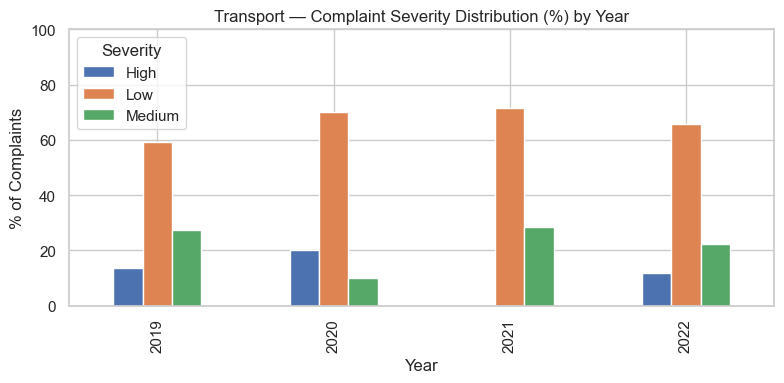

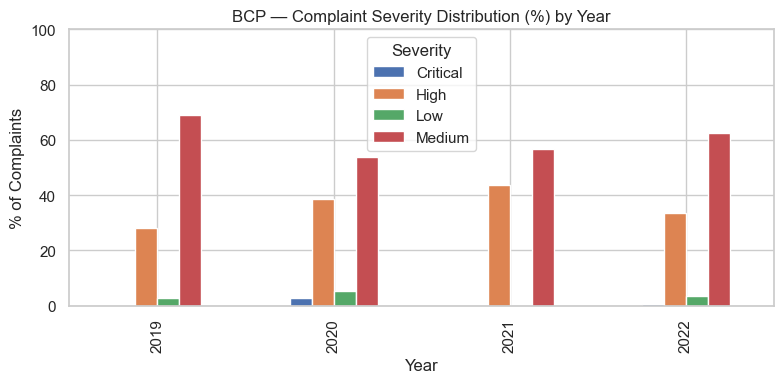

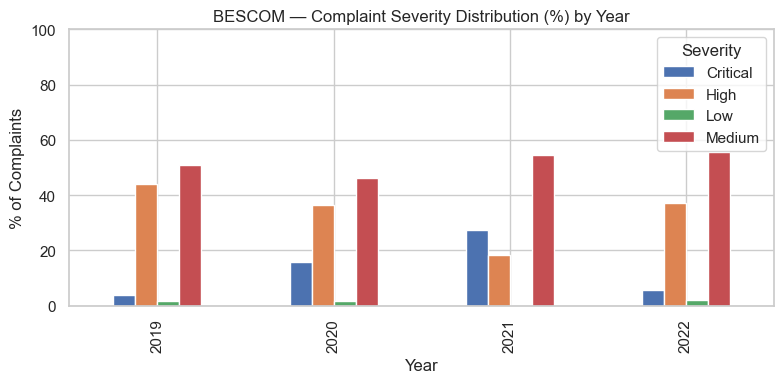

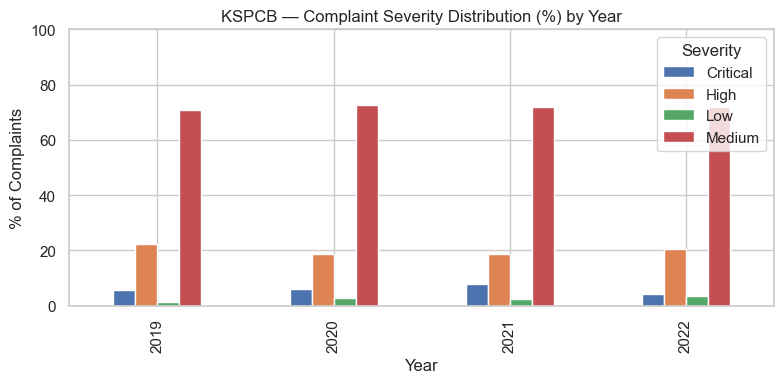

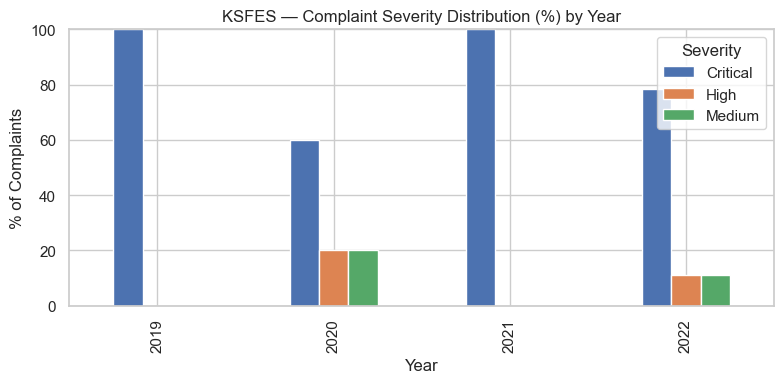

In [455]:
# Year-by-year severity breakdown per agency (percentage)
for agency in df["civic_agency_title"].dropna().unique():
    data  = df[df["civic_agency_title"] == agency]
    pivot = data.pivot_table(index="year", columns="severity", aggfunc="size", fill_value=0)
    if pivot.empty:
        continue
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    pivot_pct.plot(kind="bar", stacked=False, figsize=(8, 4))
    plt.ylim(0, 100)
    plt.title(f"{agency} — Complaint Severity Distribution (%) by Year")
    plt.xlabel("Year"); plt.ylabel("% of Complaints")
    plt.legend(title="Severity")
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / f"2.3_{agency}_severity_by_year.png", dpi=150, bbox_inches="tight")
    plt.show()


### 2.4  Category & Sub-Category Breakdown (BBMP)

BBMP is the highest-volume agency. Inspecting its categories confirms the text data contains sufficient semantic diversity for classification.


In [456]:
df_BBMP = df[df["civic_agency_title"] == "BBMP"]
print(f"BBMP categories    : {df_BBMP['category_title'].nunique()}")
print(df_BBMP["category_title"].value_counts().head(15))
print()
print(f"BBMP sub-categories: {df_BBMP['sub_category_title'].nunique()}")
print(df_BBMP["sub_category_title"].value_counts().head(15))


BBMP categories    : 18
category_title
Mobility - Roads, Footpaths and Infrastructure    5048
Garbage and Unsanitary Practices                  3923
Yellow Spot                                        933
Animal Husbandry                                   848
Street lighting                                    807
Streetlights                                       693
Community Infrastructure and Services              133
Storm Water Drains                                 124
Parks & Recreation                                 121
Trees and Saplings                                 104
Public Toilets                                      56
Certificates                                        53
Lakes                                               52
Mobility - Roads, Public transport                  11
Playgrounds                                          7
Name: count, dtype: int64

BBMP sub-categories: 110
sub_category_title
Clearance Of Garbage Dump Or Black Spot               3110
Fixing

---
## 3  Civic Agency Classification — Preprocessing, Augmentation & Training

**Objective:** Given the free-text description of a complaint, predict which civic agency (*BBMP, BWSSB, BESCOM, BTP, Transport, …*) should handle it.

**Training strategy:** 5-fold stratified cross-validation. Each training fold is augmented independently before fitting; the model is evaluated on the untouched validation fold to prevent data leakage.


In [457]:
df= df[['description','civic_agency_title','severity','complaint_length']]
df.head()

,description,civic_agency_title,severity,complaint_length
0,Govt Road is encroached by Private buildings i...,BBMP,High,19
1,My property SAS base app no 1600800634 New Pid...,BBMP,Low,23
2,Extremely dangerous BTP barrier in the middle ...,BBMP,Critical,34
3,Lat few days there is no proper water supply i...,BWSSB,High,66
4,Garbage dump at chamundeshwari layout 1st cros...,BBMP,Medium,25


### 3.1  Train / Test Split


In [438]:
X = df["description"]
y = df["civic_agency_title"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"\nClass distribution (train):")
print(y_train.value_counts())

Training samples : 13,196
Test samples     : 3,299

Class distribution (train):
civic_agency_title
BBMP         10343
BWSSB          866
BTP            864
KSPCB          431
BCP            264
BESCOM         262
Transport       85
KSFES           81
Name: count, dtype: int64


### 3.2  Text Preprocessing

Each complaint passes through:
1. Lowercasing
2. Boilerplate removal (greetings, sign-offs)
3. URL removal
4. Non-alphabetic character removal
5. Whitespace normalisation
6. Stopword removal + Lemmatisation


In [439]:
# ── NLTK setup ────────────────────────────────────────────────────────────────
local_nltk_path = PROJECT_ROOT / "data" / "nltk"
local_nltk_path.mkdir(parents=True, exist_ok=True)
nltk.data.path.insert(0, str(local_nltk_path))

try:
    STOPWORDS   = set(stopwords.words("english"))
    _lemmatizer = WordNetLemmatizer()
    print("✅ NLTK stopwords and lemmatizer loaded.")
except LookupError:
    raise RuntimeError(f"❌ NLTK stopwords not found. Check: {local_nltk_path}")

nltk.download = lambda *args, **kwargs: True
logging.getLogger("nltk").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")

_BOILERPLATE = [
    r"dear sir.*?", r"dear madam.*?",
    r"regards.*?",  r"sent from my.*?", r"thank you.*?",
]

def preprocess(text: str) -> str:
    text = str(text).lower()
    for pat in _BOILERPLATE:
        text = re.sub(pat, " ", text, flags=re.IGNORECASE)
    text = re.sub(r"http[s]?://\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text  # No lemmatization

# Sanity check
sample = "Dear Sir, The road near my house has deep potholes. Regards, Citizen"
print(f"Before : {sample}")
print(f"After  : {preprocess(sample)}")


✅ NLTK stopwords and lemmatizer loaded.
Before : Dear Sir, The road near my house has deep potholes. Regards, Citizen
After  : the road near my house has deep potholes citizen


### 3.3  N-gram Frequency Analysis & Word Cloud

Inspecting the top unigrams, bigrams, and trigrams confirms the preprocessed text retains domain-relevant vocabulary (e.g. *road, garbage, water, drainage*) and reveals any remaining noise.


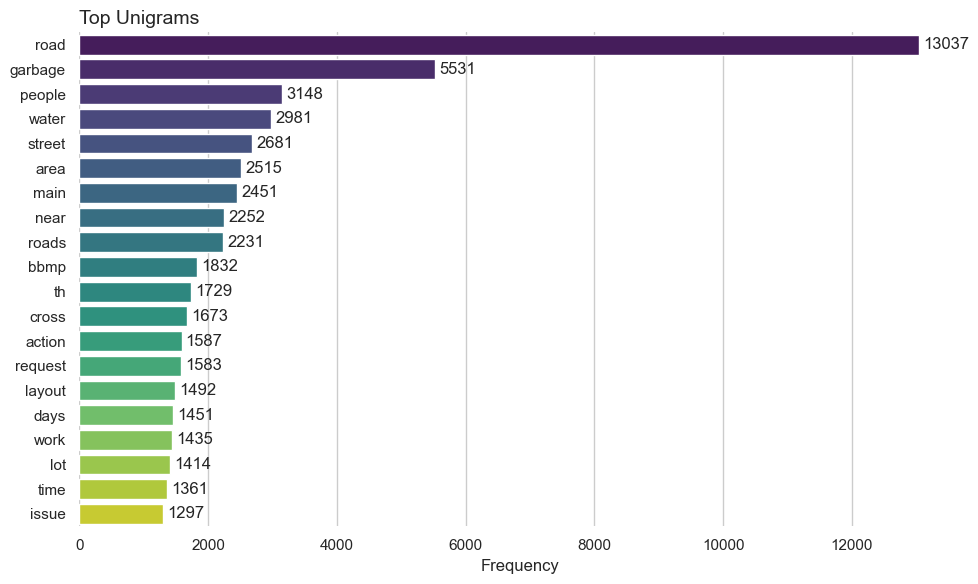

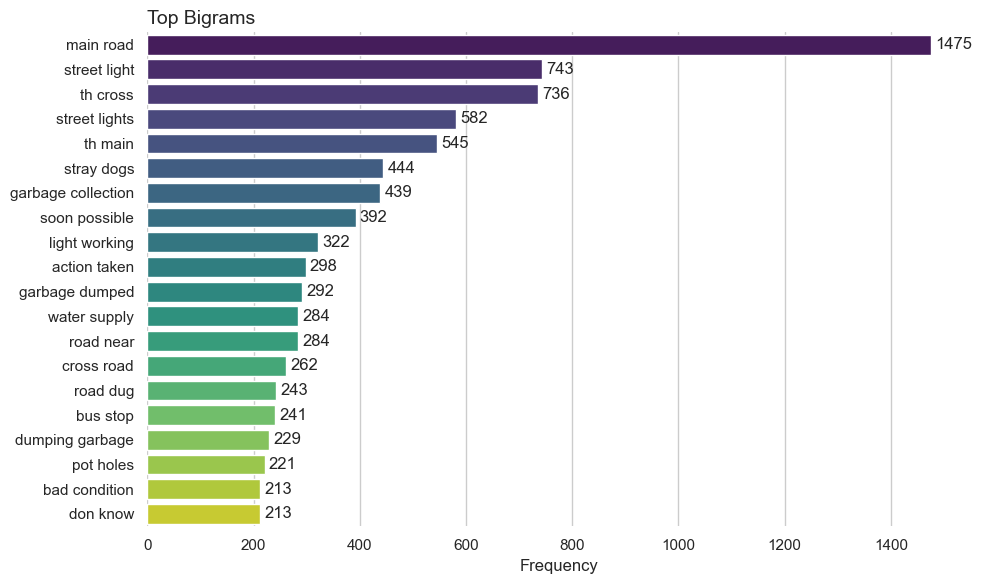

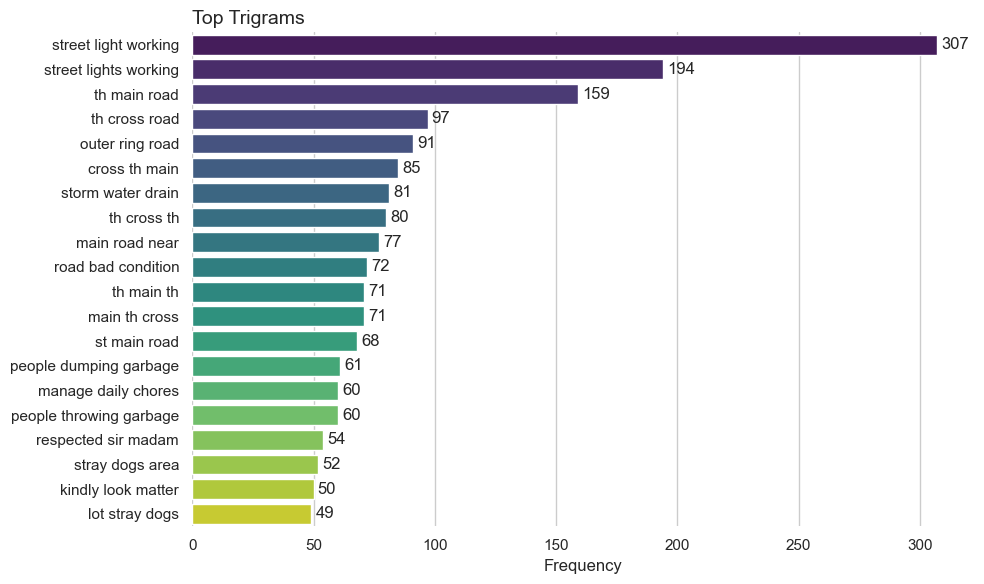

In [440]:
# Apply preprocessing to the full corpus for EDA
df["clean"] = df["description"].apply(preprocess)

def get_ngram_freq(text_series, ngram_range=(2, 2), top_k=20, min_df=10):
    if text_series.empty:
        return pd.DataFrame(columns=["ngram", "frequency"])
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df, stop_words="english")
    X_v = vec.fit_transform(text_series)
    counts = X_v.sum(axis=0).A1
    return (
        pd.DataFrame({"ngram": vec.get_feature_names_out(), "frequency": counts})
          .sort_values("frequency", ascending=False).head(top_k)
    )

def plot_ngram(df_ngram, title):
    if df_ngram.empty:
        print(f"No data for: {title}"); return
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.barplot(x="frequency", y="ngram", data=df_ngram, palette="viridis")
    plt.title(title, fontsize=14, loc="left")
    plt.xlabel("Frequency"); plt.ylabel("")
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    # savefig must come BEFORE show() to avoid saving a blank figure
    plt.savefig(CHARTS_DIR / f"3.1_{title.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

for ngram_range, title in [((1,1),"Top Unigrams"), ((2,2),"Top Bigrams"), ((3,3),"Top Trigrams")]:
    plot_ngram(get_ngram_freq(df["clean"], ngram_range=ngram_range), title)


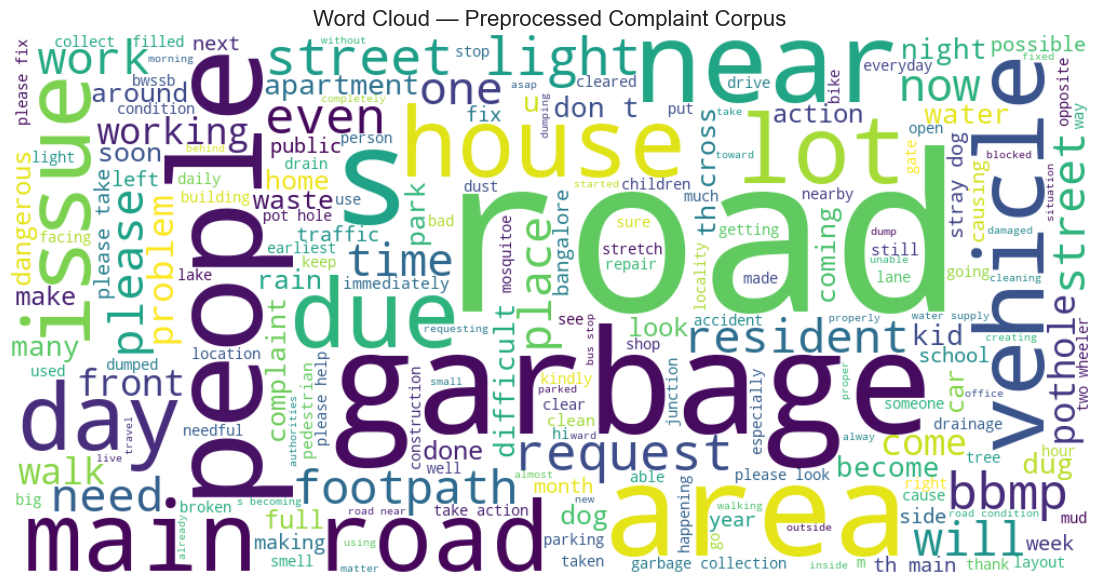

In [441]:
all_text = " ".join(df["clean"])
wc = WordCloud(width=1000, height=500, background_color="white",
               max_words=200, colormap="viridis").generate(all_text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Preprocessed Complaint Corpus", fontsize=16)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "3.2_word_cloud.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.4  Data Augmentation Setup

Class imbalance causes under-represented agencies to be poorly classified. Three complementary strategies are used:

- **Contextual word substitution** (DistilBERT) — replaces words with semantically similar alternatives
- **Synonym substitution** (WordNet) — lightweight and deterministic
- **Spelling augmentation** — injects minor typo-style noise for robustness

Complaints ≥ 256 words are **summarised** with T5 instead, as word-level substitution on very long texts adds little diversity.

**Augmentation intensity scales with class size:**

| Class size | Multiplier |
|-----------|-----------|
| > 2000 | skip |
| 501–1 500 | ×2 |
| 151–500 | ×4 |
| ≤ 150 | ×6 |


### 3.5  Preprocessing & Augmentation — Civic Agency Folds


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# AUGMENTATION SETUP
# ─────────────────────────────────────────────────────────────────────────────
#
# Pipeline overview
# -----------------
# Called ONCE on the full preprocessed training set (after train/test split,
# before StratifiedKFold). Originals are always preserved; augmentation only
# ADDS rows.
#
# Step 1 — Class-level tier (controls repeat count for ALL paths):
#   count > 500  →  ×1  (augment each sample once)
#   count > 150  →  ×2  (augment each sample twice)
#   count ≤ 150  →  ×3  (augment each sample three times)
#
# Step 2 — Per-sample routing by complaint_length (raw word count):
#   complaint_length >= 50  →  Classical augmenters (contextual word
#                               embedding substitution + spelling noise +
#                               T5 abstractive summary). All three applied
#                               in one pass → up to 3 new texts.
#   complaint_length <  50  →  Gemini sentence-level rewriting → up to
#                               3 paraphrases per call.
#
# Each sample is augmented `factor` times regardless of which path it takes.
# Classical path: `factor` independent passes, each yielding up to 3 texts.
# Gemini path:    `factor` separate API calls, each yielding up to 3 texts.
#
# Final dataset = original preprocessed texts
#               + augmented rows (both paths)
# All rows carry their original label.
# ─────────────────────────────────────────────────────────────────────────────

random.seed(43)
np.random.seed(43)

_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Augmentation device: {_device}")

# ── Gemini client ──────────────────────────────────────────────────────────────
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))
_gemini = genai.GenerativeModel("gemini-2.5-flash")

# ── Classical augmenters (long-text path) ─────────────────────────────────────
_AUG_CONTEXTUAL = naw.ContextualWordEmbsAug(
    model_path = "distilbert-base-uncased",
    action     = "substitute",
    device     = _device,
    aug_p      = 0.10,
    stopwords  = STOPWORDS - {"not", "no", "never", "against", "without"},
)

_AUG_SPELLING = naw.SpellingAug(aug_p=0.05)

_AUG_SUMMARY  = nas.AbstSummAug(
    model_path = "t5-base",
    device     = _device,
)

# Index 0 → contextual word embedding substitution
# Index 1 → spelling noise
# Index 2 → T5 abstractive summary
_CLASSICAL_AUGMENTERS: list = [_AUG_CONTEXTUAL, _AUG_SPELLING, _AUG_SUMMARY]


# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _safe_augment(augmenter, text: str) -> str | None:
    """Run a single nlpaug augmenter; return a clean string or None."""
    try:
        result = augmenter.augment(text)
        result = result[0] if isinstance(result, list) else result
        result = str(result).strip() if result else None
        return result if result and result.lower() != "nan" else None
    except Exception:
        return None


def _deduplicate(texts: list[str], original: str) -> list[str]:
    """Remove duplicates and exact matches to the original (case-insensitive)."""
    seen   = {original.lower()}
    unique = []
    for t in texts:
        key = t.lower()
        if key not in seen:
            seen.add(key)
            unique.append(t)
    return unique


def _clean_df(
    X: list, y: list, severity: list) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    df = pd.DataFrame({"x": X, "y": y, "severity": severity}).dropna()
    df["x"] = df["x"].astype(str).str.strip()
    df = df[(df["x"] != "") & (df["x"].str.lower() != "nan")]
    df = df.drop_duplicates()
    return df["x"].values, df["y"].values, df["severity"].values


# ─────────────────────────────────────────────────────────────────────────────
# PATH A — CLASSICAL AUGMENTATION (complaint_length >= 50)
# ─────────────────────────────────────────────────────────────────────────────

def classical_augment(text: str) -> list[str]:
    """
    Apply all three classical augmenters independently to one text.
    Returns up to 3 new strings; may return fewer if augmenters fail.
    Each augmenter runs on the ORIGINAL text (not chained).
    """
    results = []
    for aug in _CLASSICAL_AUGMENTERS:
        out = _safe_augment(aug, text)
        if out:
            results.append(out)
    return _deduplicate(results, text)


# ─────────────────────────────────────────────────────────────────────────────
# PATH B — GEMINI AUGMENTATION (complaint_length < 50)
# ─────────────────────────────────────────────────────────────────────────────

_GEMINI_PROMPT = """\
Rewrite the following civic complaint into {n} different natural-language \
variations. Preserve the original meaning, sentiment, and complaint intent. \
Keep the language informal and conversational — do NOT make it overly formal.

Return ONLY a valid JSON array of strings and nothing else.

Example output format:
["variation 1", "variation 2", "variation 3"]

Complaint:
"{text}"
"""

def gemini_augment(text: str, n: int = 3) -> list[str]:
    """
    Call Gemini to generate up to `n` paraphrases of a short complaint.
    Returns an empty list on any failure so callers never crash.
    """
    text = str(text).strip()
    if not text:
        return []
    try:
        response = _gemini.generate_content(
            _GEMINI_PROMPT.format(n=n, text=text)
        )
        raw = response.text.strip()
        if raw.startswith("```"):
            raw = raw.replace("```json", "").replace("```", "").strip()

        parsed = json.loads(raw)
        if not isinstance(parsed, list):
            return []

        cleaned = [
            str(item).strip() for item in parsed
            if item and str(item).strip().lower() not in ("", "nan", text.lower())
        ]
        return _deduplicate(cleaned, text)

    except Exception as e:
        logging.warning(f"gemini_augment failed: {e}")
        return []


def gemini_augment_with_retry(
    text:        str,
    n:           int   = 3,
    max_retries: int   = 3,
    backoff:     float = 2.0,
) -> list[str]:
    """gemini_augment with exponential back-off for rate-limit errors."""
    for attempt in range(1, max_retries + 1):
        results = gemini_augment(text, n=n)
        if results:
            return results
        wait = backoff ** attempt
        logging.warning(
            f"Gemini attempt {attempt}/{max_retries} failed. "
            f"Retrying in {wait:.1f}s…"
        )
        time.sleep(wait)
    return []


# ─────────────────────────────────────────────────────────────────────────────
# TIER FACTOR  (applies to BOTH paths)
# ─────────────────────────────────────────────────────────────────────────────

def _augment_factor(count: int) -> int:
    if 1000 <= count <= 2000:
        return 1
    elif 500 <= count < 1000:
        return 2
    elif 300 <= count < 500:
        return 4
    elif 200 <= count < 300:
        return 5
    elif 100 <= count < 200:
        return 8
    elif 1   <= count < 100:
        return 10
    else:
        return 0  # Safe fallback if count > 2000


# ─────────────────────────────────────────────────────────────────────────────
# MAIN AUGMENTATION ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────

def augment_dataset(
    X:                  np.ndarray,
    y:                  np.ndarray,
    severity:           np.ndarray,       # ← add this
    complaint_lengths:  np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:

    X_aug: list = list(X)
    y_aug: list = list(y)
    severity_aug: list = list(severity)    # ← add

    unique_classes, counts = np.unique(y, return_counts=True)

    for cls, count in zip(unique_classes, counts):

        factor      = _augment_factor(int(count))
        cls_mask    = (y == cls)
        cls_indices = np.where(cls_mask)[0]

        long_mask  = complaint_lengths[cls_mask] >= 50
        short_mask = ~long_mask

        print(
            f"\n  Class '{cls}' | {count:,} samples | "
            f"long≥50: {long_mask.sum()} | short<50: {short_mask.sum()} | "
            f"factor: ×{factor}"
        )

        with tqdm(
            total      = len(cls_indices) * factor,
            desc       = f"  Class '{cls}'",
            unit       = "pass",
            colour     = "cyan",
            leave      = True,
            bar_format = "{l_bar}{bar}| {n_fmt}/{total_fmt} passes "
                         "[{elapsed}<{remaining}, {rate_fmt}]  "
                         "aug_rows={postfix[0]}",
            postfix    = [len(X_aug) - len(X)],   # synthetic rows added so far
        ) as pbar:

            for i in cls_indices:
                is_long = complaint_lengths[i] >= 50

                for pass_num in range(factor):
                    if is_long:
                        new_texts = classical_augment(X[i])
                    else:
                        new_texts = gemini_augment_with_retry(X[i], n=3)

                    for t in new_texts:
                        t = preprocess(t)
                        if t and t.strip():
                            X_aug.append(t)
                            y_aug.append(cls)
                            severity_aug.append(severity[i])

                    pbar.postfix[0] = len(X_aug) - len(X)  # update live count
                    pbar.update(1)

    X_out, y_out, severity_out = _clean_df(X_aug, y_aug, severity_aug)

    assert len(X_out) == len(y_out) == len(severity_out), \ 
    "Length mismatch after augmentation"
    assert all(isinstance(x, str) and x.strip() for x in X_out), \
        "Empty or non-string texts found after augmentation"

    n_added = len(X_out) - len(X)
    print(f"\n  Original : {len(X):,}")
    print(f"  Synthetic: {n_added:,}")
    print(f"  Total    : {len(X_out):,}")

    return X_out, y_out

    # ── Final cleaning ────────────────────────────────────────────────────────
    X_out, y_out, severity_out = _clean_df(X_aug, y_aug, severity_aug)

    assert len(X_out) == len(y_out), "Length mismatch after augmentation"
    assert all(isinstance(x, str) and x.strip() for x in X_out), \
        "Empty or non-string texts found after augmentation"

    n_added = len(X_out) - len(X)
    print(f"\n  Original : {len(X):,}")
    print(f"  Synthetic: {n_added:,}")
    print(f"  Total    : {len(X_out):,}")

    return X_out, y_out, severity_out

Augmentation device: cuda


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────────────────────
#
# Augmentation happens ONCE on the full training set before folding.
# Val folds are drawn from the original preprocessed texts only —
# augmented rows are train-only and never leak into validation.
#
# Flow:
#   1. Preprocess full X_train.
#   2. Augment once → X_train_aug / y_train_aug  (originals + synthetic)
#   3. StratifiedKFold on the ORIGINAL indices only (len(X_train)).
#   4. Each fold: train slice from augmented set, val slice from originals.
#   5. Save fold_data_list.
# ─────────────────────────────────────────────────────────────────────────────

SAVE_PATH = (
    PROJECT_ROOT / "data" / "processed"
    / "cv_fold_data_augmented_civic_agencies.joblib"
)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

if SAVE_PATH.exists():
    print(f"✅ Loading cached fold data:\n  {SAVE_PATH}")
    fold_data_list = joblib.load(SAVE_PATH)
    print(f"   {len(fold_data_list)} folds loaded.")

else:
    print("⚠️  No cache found — running augmentation + 5-fold CV build...")

    # ── Step 1: preprocess the full training set ──────────────────────────────
    print("\n  Preprocessing X_train…")
    complaint_lengths_train = df.loc[X_train.index, "complaint_length"].values

    X_train_preprocessed = np.array([preprocess(t) for t in X_train.values])
    y_train_arr          = y_train.values

    # ── Step 2: Number of original samples — used to restrict val folds to originals only ───────────
    n_originals = len(X_train_preprocessed)

    # ── Step 3: StratifiedKFold on original indices only ─────────────────────
    # We split on the preprocessed originals so val folds never contain
    # synthetic rows. Train folds pull from the full augmented set.
    skf            = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_data_list = []
    
    # just before the skf.split loop
    y_train_arr_severity = df.loc[X_train.index, "severity"].values

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(X_train_preprocessed, y_train_arr)
    ):
        print(f"\n{'='*50}  Fold {fold_idx+1}/5  {'='*50}")

        # ── Val slice: originals only, no augmentation ────────────────────────
        val_X = X_train_preprocessed[val_idx]
        val_y = y_train_arr[val_idx]

        # ── Train slice: all augmented rows whose *original* index is in
        #    train_idx.  We find them by checking y_train_aug alignment:
        #    the first n_originals rows of X_train_aug are the originals
        #    (augment_dataset preserves them at the front), so we can build
        #    a boolean mask over the full augmented array.
        #
        #    Strategy: mark original train indices, then include every
        #    augmented row that was derived from those originals.
        #    Because augment_dataset appends synthetics after all originals,
        #    rows [0 : n_originals] map 1-to-1 with X_train_preprocessed.
        #    Rows [n_originals :] are synthetic — we keep them all for the
        #    train split (they came from train_idx originals only, since
        #    val originals were never augmented — augmentation ran on the
        #    full set, so we need to be careful here).
        #
        # ── Simpler and safer: re-augment only train_idx rows ─────────────────
        # The cleanest approach to guarantee no val leakage is to keep only
        # the original train_idx rows from the preprocessed set, then pull
        # the corresponding synthetic rows by rebuilding a per-sample map.
        # Since augment_dataset is deterministic (fixed seed), we can instead
        # just use train_idx on the originals + all synthetics (synthetics
        # were generated from the whole training set, so no label leakage,
        # but text from val originals could appear in synthetics).
        #
        # CLEANEST FIX: run augment_dataset per fold on train_idx slice only.
        # This is the only way to guarantee zero val-text contamination.

        train_X_raw   = X_train_preprocessed[train_idx]
        train_y_raw   = y_train_arr[train_idx]
        train_lengths = complaint_lengths_train[train_idx]
        train_severity = y_train_arr_severity[train_idx]  # ← here

        try:
            train_X_fold, train_y_fold, train_severity_fold = augment_dataset(
                X                 = train_X_raw,
                y                 = train_y_raw,
                severity          = train_severity,       # ← add
                complaint_lengths = train_lengths,
            )
        except Exception as e:
            print(f"\n  ❌ ERROR  Fold {fold_idx+1}")
            print(f"     {type(e).__name__}: {e}")
            if fold_data_list:
                joblib.dump(fold_data_list, SAVE_PATH, compress=3)
                print(
                    f"     💾 {len(fold_data_list)} completed fold(s) saved "
                    f"to:\n       {SAVE_PATH}"
                )
            raise

        fold_data_list.append({
            "train_X": train_X_fold,
            "train_y": train_y_fold,
            "train_severity": train_severity_fold,    # ← add
            "val_X":   val_X,
            "val_y":   val_y,
            "val_severity":   y_train_arr_severity[val_idx],  # ← val originals
            "val_idx": val_idx,
        })

        print(
            f"  ✅ Fold {fold_idx+1} done | "
            f"train (aug): {len(train_X_fold):,} | val (orig): {len(val_X):,}"
        )

    joblib.dump(fold_data_list, SAVE_PATH, compress=3)
    print(f"\n✅ Saved → {SAVE_PATH}")

⚠️  No cache found — running augmentation + 5-fold CV build...

  Preprocessing X_train…

  Augmenting full training set (one-time pass)…

  Class 'BBMP' | 10,343 samples | long≥50: 2718 | short<50: 7625 | factor: ×0


  Class 'BBMP': |          | 0/0 passes [00:00<?, ?pass/s]  aug_rows=0


  Class 'BCP' | 264 samples | long≥50: 194 | short<50: 70 | factor: ×5


  Class 'BCP':   0%|          | 0/1320 passes [00:00<?, ?pass/s]  aug_rows=0

KeyboardInterrupt: 

### 3.6  Shared Utilities for Grid Search

A reusable `run_grid_search()` helper runs cross-validated hyperparameter tuning for any scikit-learn pipeline, saves the best params, OOF confusion matrix, and metrics JSON — keeping the per-model cells concise.


In [ ]:
SEED = 43
random.seed(SEED); np.random.seed(SEED)

# ── Load civic-agency fold data ───────────────────────────────────────────────
fold_data_path = PROJECT_ROOT / "data" / "processed" / "cv_fold_data_augmented_civic_agencies.joblib"
fold_data = joblib.load(fold_data_path)
print("✅ Civic agency fold data loaded.")

# 1. Create an empty array the size of the full dataset (or sum of val sizes)
# Note: Since val_idx refers to indices in y_train, we should size it to len(y_train)
total_size = len(y_train) 
y_global = np.empty(total_size, dtype=object)
# 2. Fill it using the original indices
for d in fold_data:
    y_global[d["val_idx"]] = d["val_y"]
# 3. Now y_global and oof use the same index system
labels = sorted(np.unique(y_global))
print(f"Classes ({len(labels)}): {labels}")


def _next_version(path: Path, base_name: str) -> int:
    """Return the next unused version index for output files."""
    i = 1
    while (path / f"{base_name}_{i}.json").exists():
        i += 1
    return i

def run_grid_search(model_name, build_fn, param_grid, fold_data, y_global, labels, output_root):
    """
    Cross-validated grid search over param_grid.
    Saves best params, OOF confusion matrix PNG, and metrics JSON.
    Returns (best_params, best_metrics).
    """
    SEED= 43
    out_dir = output_root / model_name
    out_dir.mkdir(parents=True, exist_ok=True)
    version = _next_version(out_dir, f"results_{model_name}")
    best_f1, best_params, best_metrics = -1, None, None
    print(f"\n{'='*55}\n  GRID SEARCH — {model_name.upper()}\n{'='*55}")
    for params in ParameterGrid(param_grid):

        random.seed(SEED)
        np.random.seed(SEED)

        # Lists to store metrics per fold
        train_accs, train_precs, train_recs = [], [], []
        train_f1_macros, train_f1_micros, train_f1_weighteds = [], [], []
        
        val_accs, val_precs, val_recs = [], [], []
        val_f1_macros, val_f1_micros, val_f1_weighteds = [], [], []
        for d in fold_data:
            m = build_fn()
            random.seed(SEED)
            np.random.seed(SEED)
            m.set_params(**params)
            m.fit(d["train_X"], d["train_y"])
            
            # ── Train metrics ──
            train_preds = m.predict(d["train_X"])
            train_accs.append(accuracy_score(d["train_y"], train_preds))
            train_precs.append(precision_score(d["train_y"], train_preds, average="macro", zero_division=0))
            train_recs.append(recall_score(d["train_y"], train_preds, average="macro", zero_division=0))
            train_f1_macros.append(f1_score(d["train_y"], train_preds, average="macro"))
            train_f1_micros.append(f1_score(d["train_y"], train_preds, average="micro"))
            train_f1_weighteds.append(f1_score(d["train_y"], train_preds, average="weighted"))
            
            # ── Val metrics ──
            val_preds = m.predict(d["val_X"])
            val_accs.append(accuracy_score(d["val_y"], val_preds))
            val_precs.append(precision_score(d["val_y"], val_preds, average="macro", zero_division=0))
            val_recs.append(recall_score(d["val_y"], val_preds, average="macro", zero_division=0))
            val_f1_macros.append(f1_score(d["val_y"], val_preds, average="macro"))
            val_f1_micros.append(f1_score(d["val_y"], val_preds, average="micro"))
            val_f1_weighteds.append(f1_score(d["val_y"], val_preds, average="weighted"))
        # Averages
        avg_val_f1 = float(np.mean(val_f1_macros))
        print(f"  {params}")
        print(f"    Val  | F1-macro: {avg_val_f1:.4f} | F1-micro: {np.mean(val_f1_micros):.4f} | F1-wgt: {np.mean(val_f1_weighteds):.4f} | Acc: {np.mean(val_accs):.4f} | P: {np.mean(val_precs):.4f} | R: {np.mean(val_recs):.4f}")
        print(f"    Train| F1-macro: {np.mean(train_f1_macros):.4f} | F1-micro: {np.mean(train_f1_micros):.4f} | F1-wgt: {np.mean(train_f1_weighteds):.4f} | Acc: {np.mean(train_accs):.4f} | P: {np.mean(train_precs):.4f} | R: {np.mean(train_recs):.4f}")
        
        if avg_val_f1 > best_f1:
            best_f1 = avg_val_f1
            best_params = params
            best_metrics = {
                "val_f1_macro": float(np.mean(val_f1_macros)),
                "val_f1_micro": float(np.mean(val_f1_micros)),
                "val_f1_weighted": float(np.mean(val_f1_weighteds)),
                "val_accuracy": float(np.mean(val_accs)),
                "val_precision": float(np.mean(val_precs)),
                "val_recall": float(np.mean(val_recs)),
                "train_f1_macro": float(np.mean(train_f1_macros)),
                "train_f1_micro": float(np.mean(train_f1_micros)),
                "train_f1_weighted": float(np.mean(train_f1_weighteds)),
                "train_accuracy": float(np.mean(train_accs)),
                "train_precision": float(np.mean(train_precs)),
                "train_recall": float(np.mean(train_recs)),
            }
    print(f"\n✅ Best Val F1-macro: {best_f1:.4f}  |  Params: {best_params}")
    # OOF confusion matrix
    oof = np.empty_like(y_global, dtype=object)
    for d in fold_data:
        m = build_fn(); m.set_params(**best_params)
        m.fit(d["train_X"], d["train_y"])
        oof[d["val_idx"]] = m.predict(d["val_X"])
    cm = confusion_matrix(y_global, oof, labels=labels)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(f"Average Metrics Confusion Matrix — {model_name} (v{version})")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
    plt.tight_layout()
    cm_path = out_dir / f"grid_search_confusion_matrix_{model_name}_{version}.png"
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    results = {
        "version": version, "model": model_name,
        "best_params": {k: list(v) if isinstance(v, tuple) else v for k, v in best_params.items()},
        "metrics": best_metrics,
    }
    with open(out_dir / f"grid_search_results_{model_name}_{version}.json", "w") as fh:
        json.dump(results, fh, indent=4)
    return best_params, best_metrics

### 3.7  Logistic Regression — Civic Agency



  GRID SEARCH — LOGISTIC_REGRESSION
  {'clf__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 1)}
    Val  | F1-macro: 0.7353 | F1-micro: 0.8625 | F1-wgt: 0.8716 | Acc: 0.8625 | P: 0.6802 | R: 0.8178
    Train| F1-macro: 0.9352 | F1-micro: 0.9249 | F1-wgt: 0.9255 | Acc: 0.9249 | P: 0.9065 | R: 0.9687
  {'clf__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 2)}
    Val  | F1-macro: 0.7509 | F1-micro: 0.8750 | F1-wgt: 0.8820 | Acc: 0.8750 | P: 0.7139 | R: 0.8073
    Train| F1-macro: 0.9462 | F1-micro: 0.9362 | F1-wgt: 0.9367 | Acc: 0.9362 | P: 0.9226 | R: 0.9729
  {'clf__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 3)}
    Val  | F1-macro: 0.7410 | F1-micro: 0.8708 | F1-wgt: 0.8785 | Acc: 0.8708 | P: 0.7023 | R: 0.8002
    Train| F1-macro: 0.9406 | F1-micro: 0.9312 | F1-wgt: 0.9317 | Acc: 0.9312 | P: 0.9158 | R: 0.9689
  {'clf__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1)}
    Val  | F1-macro: 0.7302 | F1-micro: 0.

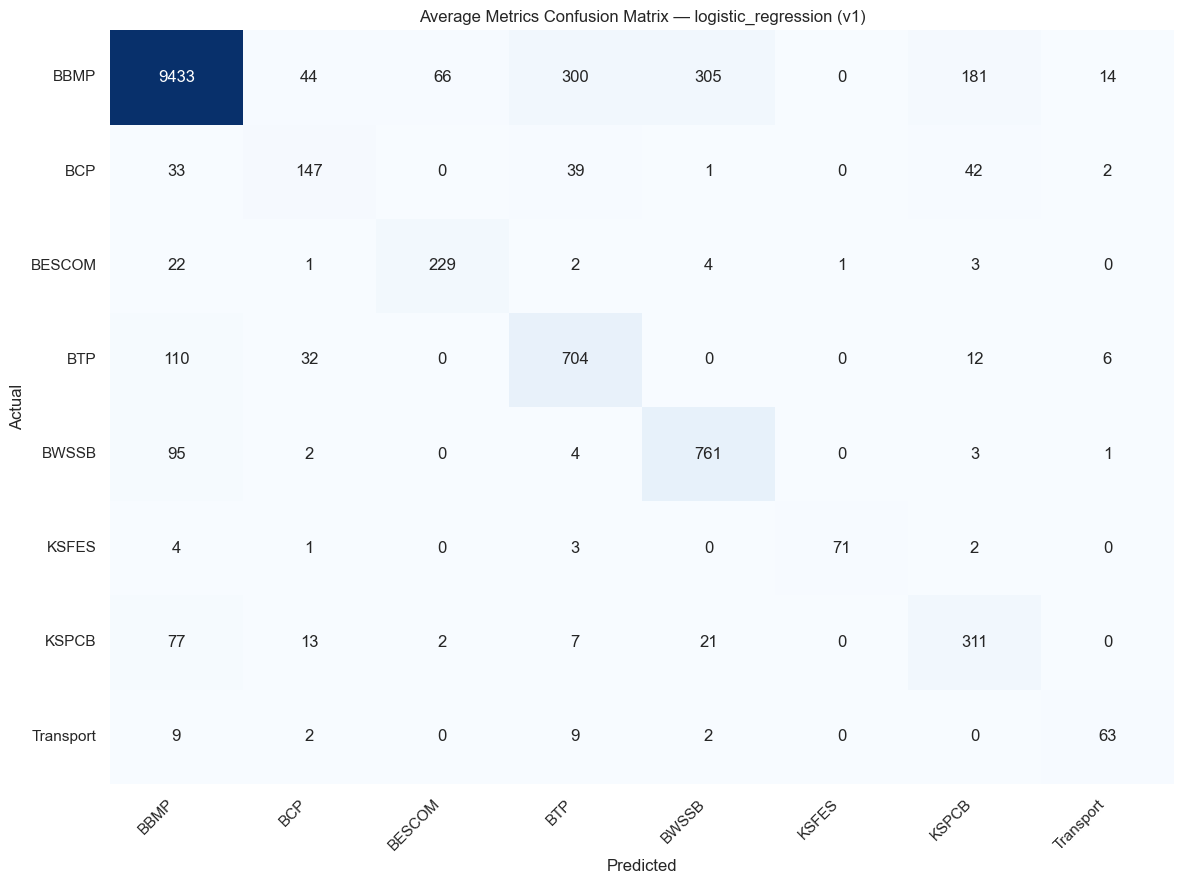

In [70]:
lr_params, lr_metrics = run_grid_search(
    model_name="logistic_regression",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("clf",   LogisticRegression(solver="lbfgs", class_weight="balanced",
                                     max_iter=2000, tol=1e-3, n_jobs=-1, random_state=SEED)),
    ]),
    param_grid={
        "tfidf__max_features": [8_000, 10_000, 12_000],
        "tfidf__ngram_range":  [(1, 1), (1, 2), (1, 3)],
        "clf__C":              [1.0, 2.0, 5.0],
    },
    fold_data=fold_data, y_global=y_global,
    labels=labels, output_root=CIVIC_OUTPUT,
)


#### Complaint-Length vs Misclassification

We test statistically whether shorter complaints are harder to classify correctly. This guides future feature engineering (e.g. minimum-length filters, length-aware models).


In [ ]:
all_texts, all_true, all_pred = [], [], []

for d in fold_data:
    m = Pipeline([
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("clf",   LogisticRegression(solver="lbfgs", class_weight="balanced",
                                     max_iter=2000, tol=1e-3, n_jobs=-1, random_state=SEED)),
    ])
    m.set_params(**lr_params)
    m.fit(d["train_X"], d["train_y"])
    preds = m.predict(d["val_X"])
    all_texts.extend(d["val_X"]); all_true.extend(d["val_y"]); all_pred.extend(preds)

analysis_df = pd.DataFrame({
    "text": all_texts, "true_label": all_true, "pred_label": all_pred,
    "complaint_length": [len(str(t).split()) for t in all_texts],
})
analysis_df["correct"] = analysis_df["true_label"] == analysis_df["pred_label"]

correct_len = analysis_df.loc[ analysis_df["correct"], "complaint_length"]
miscls_len  = analysis_df.loc[~analysis_df["correct"], "complaint_length"]

print(f"Correctly classified  : {len(correct_len):,}  | mean: {correct_len.mean():.1f} words")
print(f"Misclassified         : {len(miscls_len):,}  | mean: {miscls_len.mean():.1f} words")

_, t_p = ttest_ind(correct_len, miscls_len, equal_var=False)
_, u_p = mannwhitneyu(correct_len, miscls_len, alternative="two-sided")
n1, n2 = len(correct_len), len(miscls_len)
pooled_std = np.sqrt(((n1-1)*correct_len.std()**2 + (n2-1)*miscls_len.std()**2) / (n1+n2-2))
cohens_d   = (miscls_len.mean() - correct_len.mean()) / (pooled_std + 1e-9)

size = ("Negligible" if abs(cohens_d) < 0.2 else
        "Small"      if abs(cohens_d) < 0.5 else
        "Medium"     if abs(cohens_d) < 0.8 else "Large")
sig  = "✅ Significant" if u_p < 0.05 else "❌ Not significant"

print(f"\nMann-Whitney p = {u_p:.2e}  |  Cohen's d = {cohens_d:.3f} ({size})")
print(f"Result: {sig} — errors are driven more by semantic ambiguity than complaint length.")


### 3.8  LinearSVC — Civic Agency


In [ ]:
svc_params, svc_metrics = run_grid_search(
    model_name="linearsvc",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   LinearSVC(penalty="l2", multi_class="ovr", class_weight="balanced",
                            max_iter=2000, dual="auto", random_state=SEED)),
    ]),
    param_grid={
        "tfidf__max_features": [1_000, 3_000, 5_000],
        "tfidf__ngram_range":  [(1, 1), (1, 2)],
        "clf__C":              [0.1, 1.0, 5.0],
    },
    fold_data=fold_data, y_global=y_global,
    labels=labels, output_root=CIVIC_OUTPUT,
)


### 3.9  Random Forest — Civic Agency


In [ ]:
rf_params, rf_metrics = run_grid_search(
    model_name="random_forest",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   RandomForestClassifier(min_samples_split=2, min_samples_leaf=1,
                                          random_state=SEED, n_jobs=-1)),
    ]),
    param_grid={
        "tfidf__max_features":   [300, 700, 1_000],
        "tfidf__ngram_range":    [(1, 1), (1, 2)],
        "clf__n_estimators":     [100, 200],
        "clf__max_depth":        [None, 20],
        "clf__min_samples_split":[2, 5],
    },
    fold_data=fold_data, y_global=y_global,
    labels=labels, output_root=CIVIC_OUTPUT,
)

# Quick misclassification inspection
oof_rf = np.empty_like(y_global, dtype=object)
for d in fold_data:
    m = Pipeline([("tfidf", TfidfVectorizer()), ("clf", RandomForestClassifier(random_state=SEED))])
    m.set_params(**rf_params); m.fit(d["train_X"], d["train_y"])
    oof_rf[d["val_idx"]] = m.predict(d["val_X"])

mis_idx = np.where(y_global != oof_rf)[0]
print("\nSample misclassified complaints:")
for i in mis_idx[:10]:
    print(f"  Actual: {y_global[i]:12s} | Pred: {oof_rf[i]:12s} | {str(df.iloc[i]['description'])[:80]}")
    print("  " + "-"*80)


### 3.10  Civic Agency Model Comparison


In [ ]:
print(f"{'Model':<22} {'F1-Macro':>9} {'Accuracy':>9} {'Precision':>10} {'Recall':>8}")
print("-"*62)
for name, m in [("Logistic Regression", lr_metrics),
                ("LinearSVC",           svc_metrics),
                ("Random Forest",       rf_metrics)]:
    print(f"{name:<22} {m['f1_macro']:>9.4f} {m['accuracy']:>9.4f} {m['precision']:>10.4f} {m['recall']:>8.4f}")


---
## 4  Civic Agency Classification — Final Dataset & Model Saving

We re-train the best model on the **full training set** and save it for production use, alongside a clean preprocessed dataset for future experiments.


In [ ]:
final_dataset_path = PROJECT_ROOT / "data" / "processed" / "final_dataset.joblib"

if final_dataset_path.exists():
    print(f"✅ Loading existing final dataset:\n  {final_dataset_path}")
    dataset = joblib.load(final_dataset_path)
    X_final = dataset["X"]; y_final = dataset["y"]; labels_final = dataset["labels"]
    print(f"   Total samples: {dataset['num_samples']:,}")
else:
    print("⚠️  Building final dataset from scratch...")
    df_final = (
        df.dropna(subset=["description", "civic_agency_title"]).copy()
    )
    df_final["clean"] = df_final["description"].apply(preprocess)
    df_final = df_final[df_final["clean"].str.strip() != ""]
    df_final = df_final.drop_duplicates(subset=["clean", "civic_agency_title"])

    X_final = df_final["clean"].values
    y_final = df_final["civic_agency_title"].values
    labels_final = np.unique(y_final)

    dataset = {
        "X": X_final, "y": y_final, "labels": labels_final,
        "raw_text":    df_final["description"].values,
        "version":     "v1_clean_no_aug",
        "num_samples": len(X_final),
        "indices":     df_final.index.to_numpy(),
        "class_counts": dict(pd.Series(y_final).value_counts()),
    }
    joblib.dump(dataset, final_dataset_path, compress=3)
    print(f"✅ Saved: {final_dataset_path} ({len(X_final):,} samples)")


---
## 5  Severity Classification — Preprocessing, Augmentation, Training & Inference

**Objective:** Predict complaint urgency — *Low, Medium, High,* or *Critical*.

**Why severity is harder:**
- The linguistic boundary between *High* and *Critical* is subjective.
- *Critical* complaints are rare (class imbalance).
- Misclassifying *Critical* as *Low* has real operational consequences.

**Approach:**  
We optimise for **Critical recall** rather than overall accuracy, using three progressively more targeted strategies:

| Model | Key technique |
|-------|---------------|
| Classical ML (LR, SVC, RF, MNB) | TF-IDF + balanced class weights |
| DistilBERT Model 1 | Weighted Cross-Entropy |
| DistilBERT Model 2 | Focal Loss + ordinal penalty matrix |
| DistilBERT Model 3 | Weighted CE + cascaded waterfall thresholds |
| BiLSTM | Focal Loss + ordinal penalty (native PyTorch) |


### 5.1  Preprocessing & Augmentation — Severity Folds


In [ ]:
random.seed(42); np.random.seed(42)

save_path_sev = PROJECT_ROOT / "data" / "processed" / "cv_fold_data_augmented_severity.joblib"
save_path_sev.parent.mkdir(parents=True, exist_ok=True)

if save_path_sev.exists():
    print(f"✅ Loading cached severity folds:\n  {save_path_sev}")
    fold_data_sev = joblib.load(save_path_sev)
    print(f"   {len(fold_data_sev)} folds loaded.")
else:
    print("⚠️  Building severity folds from scratch...")
    df_sev = df.dropna(subset=["description", "severity"]).copy()
    df_sev["clean"] = df_sev["description"].apply(preprocess)

    X_sev = df_sev["clean"].values
    y_sev = df_sev["severity"].values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_data_sev = []
    for fold_id, (tr_idx, va_idx) in enumerate(skf.split(X_sev, y_sev)):
        print(f"  Processing fold {fold_id+1}/5 ...")
        X_tr, X_va = X_sev[tr_idx], X_sev[va_idx]
        y_tr, y_va = y_sev[tr_idx], y_sev[va_idx]
        X_tr_aug, y_tr_aug = augment_dataset(X_tr, y_tr)
        fold_data_sev.append({
            "train_X": X_tr_aug, "train_y": y_tr_aug,
            "val_X": X_va, "val_y": y_va, "val_idx": va_idx,
        })

    joblib.dump(fold_data_sev, save_path_sev, compress=3)
    print(f"✅ Saved: {save_path_sev}")


### 5.2  Classical Models — Severity Classification


In [ ]:
all_val_y_sev = []
for d in fold_data_sev:
    all_val_y_sev.extend(d["val_y"])
y_sev_global = np.array(all_val_y_sev)
labels_sev   = sorted(np.unique(y_sev_global))
print(f"Severity classes: {labels_sev}")

SEV_OUTPUT = PROJECT_ROOT / "metrics_model_severity"

# ── 5.2.1  Logistic Regression ────────────────────────────────────────────────
lr_sev_params, lr_sev_metrics = run_grid_search(
    model_name="logistic_regression",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer(sublinear_tf=True)),
        ("clf",   LogisticRegression(solver="lbfgs", class_weight="balanced",
                                     max_iter=2000, tol=1e-3, random_state=SEED)),
    ]),
    param_grid={
        "tfidf__max_features": [8_000, 10_000, 12_000],
        "tfidf__ngram_range":  [(1, 1), (1, 2), (1, 3)],
        "clf__C":              [1.0, 2.0, 5.0],
    },
    fold_data=fold_data_sev, y_global=y_sev_global,
    labels=labels_sev, output_root=SEV_OUTPUT,
)

# ── 5.2.2  LinearSVC ──────────────────────────────────────────────────────────
svc_sev_params, svc_sev_metrics = run_grid_search(
    model_name="linearsvc",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   LinearSVC(penalty="l2", multi_class="ovr", class_weight="balanced",
                            max_iter=2000, dual="auto", random_state=SEED)),
    ]),
    param_grid={
        "tfidf__max_features": [1_000, 3_000, 5_000],
        "tfidf__ngram_range":  [(1, 1), (1, 2)],
        "clf__C":              [0.1, 1.0, 5.0],
    },
    fold_data=fold_data_sev, y_global=y_sev_global,
    labels=labels_sev, output_root=SEV_OUTPUT,
)

# ── 5.2.3  Random Forest ──────────────────────────────────────────────────────
rf_sev_params, rf_sev_metrics = run_grid_search(
    model_name="random_forest",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   RandomForestClassifier(min_samples_split=2, min_samples_leaf=1,
                                          random_state=SEED, n_jobs=-1)),
    ]),
    param_grid={
        "tfidf__max_features":   [300, 700, 1_000],
        "tfidf__ngram_range":    [(1, 1), (1, 2)],
        "clf__n_estimators":     [100, 200],
        "clf__max_depth":        [None, 20],
        "clf__min_samples_split":[2, 5],
    },
    fold_data=fold_data_sev, y_global=y_sev_global,
    labels=labels_sev, output_root=SEV_OUTPUT,
)

# ── 5.2.4  Multinomial Naive Bayes ────────────────────────────────────────────
mnb_sev_params, mnb_sev_metrics = run_grid_search(
    model_name="multinomialnb",
    build_fn=lambda: Pipeline([
        ("tfidf", TfidfVectorizer(sublinear_tf=True, stop_words="english")),
        ("clf",   MultinomialNB()),
    ]),
    param_grid={
        "tfidf__max_features": [1_000, 3_000, 5_000],
        "tfidf__ngram_range":  [(1, 1), (1, 2)],
        "clf__alpha":          [0.1, 0.5, 1.0, 2.0, 5.0],
    },
    fold_data=fold_data_sev, y_global=y_sev_global,
    labels=labels_sev, output_root=SEV_OUTPUT,
)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*62}")
print(f"  CLASSICAL MODEL COMPARISON — SEVERITY")
print(f"{'='*62}")
print(f"{'Model':<22} {'F1-Macro':>9} {'Accuracy':>9} {'Precision':>10} {'Recall':>8}")
print("-"*62)
for name, m in [("Logistic Regression", lr_sev_metrics),
                ("LinearSVC",           svc_sev_metrics),
                ("Random Forest",       rf_sev_metrics),
                ("Multinomial NB",      mnb_sev_metrics)]:
    print(f"{name:<22} {m['f1_macro']:>9.4f} {m['accuracy']:>9.4f} {m['precision']:>10.4f} {m['recall']:>8.4f}")


### 5.3  DistilBERT Fine-tuning — Severity Classification

Three models are evaluated. Each builds on the previous iteration's failure mode:

**Model 1 — Weighted Cross-Entropy (baseline)**  
Standard fine-tuning with class weights inversely proportional to frequency.

**Model 2 — Focal Loss + Ordinal Penalty**  
Focal Loss down-weights easy examples. The ordinal penalty matrix additionally penalises *under-severity* predictions (predicting Medium for a Critical complaint) more than *over-severity* predictions.

**Model 3 — Waterfall Threshold Inference**  
Same Weighted CE training as Model 1, but at inference time probabilities are evaluated in severity order (Critical → High → Medium → Low). The Critical threshold is tuned per fold to achieve ≥ 98 % recall on Critical complaints.

All models use: fp16 mixed precision · gradient checkpointing · fused AdamW · early stopping.


In [ ]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

# ── Label encoding ────────────────────────────────────────────────────────────
all_labels_bert = []
for fold in fold_data_sev:
    all_labels_bert.extend(fold["train_y"])
    all_labels_bert.extend(fold["val_y"])

le = LabelEncoder()
le.fit(all_labels_bert)
num_labels = len(le.classes_)
print(f"Severity classes ({num_labels}): {list(le.classes_)}")

# Asymmetric class weights: Critical complaints are the most costly to miss
CLASS_WEIGHT_LOOKUP = {"Critical": 4.0, "High": 3.0, "Medium": 2.0, "Low": 1.0}
class_weights_tensor = torch.tensor(
    [CLASS_WEIGHT_LOOKUP.get(lbl, 1.0) for lbl in le.classes_], dtype=torch.float32
)
print("Class weights:", {lbl: CLASS_WEIGHT_LOOKUP.get(lbl, 1.0) for lbl in le.classes_})

tokenizer     = AutoTokenizer.from_pretrained("distilbert-base-uncased")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


class ComplaintDataset(Dataset):
    """Tokenise complaints once; padding is handled dynamically per batch by DataCollator."""
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=256)
        self.labels    = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    prec, rec, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy":           accuracy_score(labels, preds),
        "f1_macro":           f1_score(labels, preds, average="macro",    zero_division=0),
        "f1_weighted":        f1_w,
        "precision_weighted": prec,
        "recall_weighted":    rec,
    }


_BERT_TRAIN_ARGS = dict(
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    fp16                        = True,
    gradient_checkpointing      = True,
    num_train_epochs            = 3,
    learning_rate               = 1e-4,
    warmup_ratio                = 0.1,
    logging_strategy            = "epoch",
    evaluation_strategy         = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    max_grad_norm               = 1.0,
    optim                       = "adamw_torch_fused",
    report_to                   = "none",
)


In [ ]:
# ── Weighted Cross-Entropy Trainer ────────────────────────────────────────────
class WeightedCETrainer(Trainer):
    """HuggingFace Trainer with class-weighted cross-entropy loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(model.device)
        )(outputs.logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


# ── Ordinal penalty matrix ────────────────────────────────────────────────────
# Under-severity errors (e.g. predicting Low for Critical) are penalised
# twice as heavily per rank step as over-severity errors.
severity_rank  = {"Critical": 3, "High": 2, "Medium": 1, "Low": 0}
penalty_matrix = torch.zeros((num_labels, num_labels))
for i, true_lbl in enumerate(le.classes_):
    for j, pred_lbl in enumerate(le.classes_):
        diff = severity_rank[true_lbl] - severity_rank[pred_lbl]
        penalty_matrix[i, j] = diff * 2.0 if diff > 0 else abs(diff) * 0.3

print("Ordinal penalty matrix (rows=true, cols=predicted):")
print(pd.DataFrame(penalty_matrix.numpy(), index=le.classes_, columns=le.classes_).round(1))


# ── Focal Loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss with optional per-class alpha weighting and ordinal penalty.

    gamma  : Focusing parameter (default 2.0). Higher values suppress easy examples.
    alpha  : Per-class weight tensor.
    penalty: (num_labels × num_labels) ordinal penalty matrix.
    """
    def __init__(self, alpha=None, gamma=2.0, penalty=None):
        super().__init__()
        self.alpha   = alpha
        self.gamma   = gamma
        self.penalty = penalty
        self.ce      = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce_loss = self.ce.to(logits.device)(logits, targets)
        pt      = torch.exp(-ce_loss)
        focal   = (1 - pt) ** self.gamma * ce_loss
        if self.alpha is not None:
            focal = self.alpha.to(logits.device)[targets] * focal
        if self.penalty is not None:
            probs = torch.softmax(logits, dim=1)
            ep    = torch.sum(probs * self.penalty.to(logits.device)[targets], dim=1)
            focal = focal * (1 + ep)
        return focal.mean()


class FocalLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, gamma=2.0, penalty=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = FocalLoss(alpha=class_weights, gamma=gamma, penalty=penalty)
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = self.loss_fct(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


In [ ]:
# ── Helper: run one DistilBERT cross-validation experiment ────────────────────
def run_bert_cv(trainer_cls, metrics_dir, checkpoint_dir,
                trainer_kwargs=None, compute_metrics_fn=None):
    """
    Runs 5-fold cross-validation for a DistilBERT-based Trainer.
    Returns (fold_results list, cms list).
    """
    metrics_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    if compute_metrics_fn is None:
        compute_metrics_fn = compute_metrics
    if trainer_kwargs is None:
        trainer_kwargs = {}

    all_results, all_cms = [], []

    for fold_id, fold in enumerate(fold_data_sev):
        print(f"\n{'='*40}\n  FOLD {fold_id}\n{'='*40}")

        y_tr = le.transform(fold["train_y"])
        y_va = le.transform(fold["val_y"])

        model = AutoModelForSequenceClassification.from_pretrained(
            "distilbert-base-uncased", num_labels=num_labels
        )
        args  = TrainingArguments(
            output_dir=str(checkpoint_dir / f"fold_{fold_id}"),
            **_BERT_TRAIN_ARGS
        )
        trainer = trainer_cls(
            model=model, args=args,
            train_dataset=ComplaintDataset(fold["train_X"], y_tr),
            eval_dataset =ComplaintDataset(fold["val_X"],   y_va),
            data_collator=data_collator,
            compute_metrics=compute_metrics_fn,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            **trainer_kwargs,
        )
        trainer.train()
        res = trainer.evaluate()
        clean = {k.replace("eval_", ""): round(float(v), 4)
                 for k, v in res.items() if isinstance(v, (int, float))}
        clean["fold"] = fold_id
        all_results.append(clean)

        preds_obj = trainer.predict(ComplaintDataset(fold["val_X"], y_va))
        preds_arr = np.argmax(preds_obj.predictions, axis=1)
        all_cms.append(confusion_matrix(y_va, preds_arr))

        with open(metrics_dir / f"fold_{fold_id}.json", "w") as fh:
            json.dump(clean, fh, indent=4)
        print(f"  Acc {clean['accuracy']:.4f} | F1-Macro {clean['f1_macro']:.4f}")

        del model, trainer
        torch.cuda.empty_cache()

    df_r = pd.DataFrame(all_results)
    summary = {"mean": df_r.mean(numeric_only=True).round(4).to_dict(),
               "std":  df_r.std(numeric_only=True).round(4).to_dict()}
    with open(metrics_dir / "summary.json", "w") as fh:
        json.dump(summary, fh, indent=4)

    avg_cm = np.mean(all_cms, axis=0)
    plt.figure(figsize=(7, 5))
    sns.heatmap(avg_cm, annot=True, fmt=".1f", cmap="Blues", cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Average Confusion Matrix — {metrics_dir.name}")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(metrics_dir / "average_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n===== SUMMARY: {metrics_dir.name} =====")
    print(pd.DataFrame(summary))
    return all_results, all_cms


In [ ]:
# ── Model 1: Weighted Cross-Entropy ──────────────────────────────────────────
results_m1, cms_m1 = run_bert_cv(
    trainer_cls   = WeightedCETrainer,
    metrics_dir   = SEV_OUTPUT / "distilbert" / "model_1",
    checkpoint_dir= PROJECT_ROOT / "checkpoints" / "distilbert" / "model_1",
)


#### Observation — Critical Class Recall

The confusion matrix for Model 1 shows that *Critical* complaints are frequently predicted as *High*. This is the most operationally dangerous error.

**Root cause:** Standard weighted cross-entropy still optimises an average loss across all classes. The asymmetric cost of under-severity errors is not explicitly encoded.

**Fix → Model 2:** Focal Loss with an ordinal penalty matrix directly penalises severity underestimation proportional to the rank difference.


In [ ]:
# ── Model 2: Focal Loss + Ordinal Penalty ─────────────────────────────────────
results_m2, cms_m2 = run_bert_cv(
    trainer_cls   = FocalLossTrainer,
    metrics_dir   = SEV_OUTPUT / "distilbert" / "model_2",
    checkpoint_dir= PROJECT_ROOT / "checkpoints" / "distilbert" / "model_2",
    trainer_kwargs= dict(
        class_weights=class_weights_tensor,
        gamma=2.0,
        penalty=penalty_matrix,
    ),
)


#### Model 3 — Cascaded Waterfall Threshold Inference

After evaluating Models 1 and 2, Critical recall still falls short of the 98 % production target. We adopt a hard cascade rule at inference time:

1. If `P(Critical) ≥ t_critical` → Critical  
2. Else if `P(High) ≥ t_high` → High  
3. Else if `P(Medium) ≥ t_medium` → Medium  
4. Otherwise → Low  

`t_critical` is tuned independently per fold using the precision-recall curve targeting ≥ 98 % recall.


In [ ]:
CRITICAL_IDX = list(le.classes_).index("Critical")
HIGH_IDX     = list(le.classes_).index("High")
LOW_IDX      = list(le.classes_).index("Low")
MEDIUM_IDX   = list(le.classes_).index("Medium")

BASE_THRESHOLDS = {"critical": 0.10, "high": 0.15, "medium": 0.20}
TARGET_CRITICAL_RECALL = 0.98


def waterfall_predict(logits: np.ndarray, thresholds: dict = None) -> np.ndarray:
    """Cascade class probabilities in severity order to produce final predictions."""
    if thresholds is None:
        thresholds = BASE_THRESHOLDS
    probs = softmax(logits, axis=1)
    preds = []
    for row in probs:
        if   row[CRITICAL_IDX] >= thresholds["critical"]:
            preds.append(CRITICAL_IDX)
        elif row[HIGH_IDX]     >= thresholds["high"]:
            preds.append(HIGH_IDX)
        elif row[MEDIUM_IDX]   >= thresholds["medium"]:
            preds.append(MEDIUM_IDX)
        else:
            preds.append(LOW_IDX)
    return np.array(preds)


def compute_metrics_waterfall(eval_pred):
    logits, labels = eval_pred
    preds = waterfall_predict(logits)
    prec, rec, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy":           accuracy_score(labels, preds),
        "f1_macro":           f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted":        f1_w,
        "precision_weighted": prec,
        "recall_weighted":    rec,
    }


In [ ]:
# ── Model 3: Waterfall Threshold ──────────────────────────────────────────────
metrics_dir_3    = SEV_OUTPUT / "distilbert" / "model_3"
checkpoint_dir_3 = PROJECT_ROOT / "checkpoints" / "distilbert" / "model_3"
metrics_dir_3.mkdir(parents=True, exist_ok=True)
checkpoint_dir_3.mkdir(parents=True, exist_ok=True)

all_results_m3, all_cms_m3 = [], []

for fold_id, fold in enumerate(fold_data_sev):
    print(f"\n{'='*40}\n  FOLD {fold_id}  |  Model 3 (Waterfall)\n{'='*40}")

    y_tr = le.transform(fold["train_y"])
    y_va = le.transform(fold["val_y"])

    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=num_labels
    )
    args    = TrainingArguments(
        output_dir=str(checkpoint_dir_3 / f"fold_{fold_id}"), **_BERT_TRAIN_ARGS
    )
    trainer = WeightedCETrainer(
        model=model, args=args,
        train_dataset=ComplaintDataset(fold["train_X"], y_tr),
        eval_dataset =ComplaintDataset(fold["val_X"],   y_va),
        data_collator=data_collator,
        compute_metrics=compute_metrics_waterfall,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    # Tune Critical threshold on this fold's validation set
    preds_obj    = trainer.predict(ComplaintDataset(fold["val_X"], y_va))
    raw_logits   = preds_obj.predictions
    val_probs    = softmax(raw_logits, axis=1)
    binary_true  = (y_va == CRITICAL_IDX).astype(int)
    precs_curve, recs_curve, pr_thresholds = precision_recall_curve(
        binary_true, val_probs[:, CRITICAL_IDX]
    )

    # Find the lowest threshold that still achieves the recall target
    optimal_t = BASE_THRESHOLDS["critical"]
    for p, r, t in zip(precs_curve[:-1], recs_curve[:-1], pr_thresholds):
        if r >= TARGET_CRITICAL_RECALL:
            optimal_t = float(t)
            break
    print(f"  Optimal Critical threshold: {optimal_t:.3f}")

    fold_thresholds = {**BASE_THRESHOLDS, "critical": optimal_t}
    preds_arr       = waterfall_predict(raw_logits, fold_thresholds)
    cm              = confusion_matrix(y_va, preds_arr)
    all_cms_m3.append(cm)

    per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-9)
    res = trainer.evaluate()
    clean = {k.replace("eval_", ""): round(float(v), 4)
             for k, v in res.items() if isinstance(v, (int, float))}
    clean["fold"] = fold_id
    clean["critical_threshold"] = round(optimal_t, 4)
    for cls, acc in zip(le.classes_, per_class_acc):
        clean[f"acc_{cls.lower()}"] = round(float(acc), 4)

    all_results_m3.append(clean)
    with open(metrics_dir_3 / f"fold_{fold_id}.json", "w") as fh:
        json.dump(clean, fh, indent=4)
    print(f"  Acc {clean['accuracy']:.4f} | F1-Macro {clean['f1_macro']:.4f} | "
          f"Critical acc {clean.get('acc_critical', 0):.4f}")

    del model, trainer
    torch.cuda.empty_cache()

df_m3 = pd.DataFrame(all_results_m3)
summary_m3 = {"mean": df_m3.mean(numeric_only=True).round(4).to_dict(),
               "std":  df_m3.std(numeric_only=True).round(4).to_dict()}
with open(metrics_dir_3 / "summary.json", "w") as fh:
    json.dump(summary_m3, fh, indent=4)

avg_cm3 = np.mean(all_cms_m3, axis=0)
plt.figure(figsize=(7, 5))
sns.heatmap(avg_cm3, annot=True, fmt=".1f", cmap="Blues", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Average Confusion Matrix — DistilBERT Model 3 (Waterfall)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(metrics_dir_3 / "average_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n===== MODEL 3 SUMMARY =====")
print(pd.DataFrame(summary_m3))


### 5.4  BiLSTM — Severity Classification

A two-layer bidirectional LSTM using the DistilBERT tokeniser vocabulary. It uses **masked mean pooling** (ignoring padding tokens) and the same Focal Loss + ordinal penalty as Model 2.


In [ ]:
class BiLSTMClassifier(nn.Module):
    """
    Two-layer bidirectional LSTM for text classification.

    Embedding → BiLSTM (×2) → masked mean pooling → Dropout → Linear.
    Masked mean pooling ignores padding positions, producing a cleaner
    sentence representation than using the final hidden state.
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_classes=4, num_layers=2, bidirectional=True,
                 dropout=0.3, pad_token_id=0):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_token_id)
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                                  bidirectional=bidirectional, batch_first=True, dropout=dropout)
        lstm_out        = hidden_dim * (2 if bidirectional else 1)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_out, num_classes)

    def forward(self, input_ids, attention_mask):
        emb      = self.embedding(input_ids)
        out, _   = self.lstm(emb)
        mask     = attention_mask.unsqueeze(-1).expand(out.size()).float()
        pooled   = torch.sum(out * mask, dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.classifier(self.dropout(pooled))


class PaddedDataset(Dataset):
    """Fixed-length padded dataset for native PyTorch DataLoaders."""
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.enc    = tokenizer(list(texts), truncation=True,
                                padding="max_length", max_length=max_length)
        self.labels = labels
    def __getitem__(self, idx):
        return {
            "input_ids":      torch.tensor(self.enc["input_ids"][idx],      dtype=torch.long),
            "attention_mask": torch.tensor(self.enc["attention_mask"][idx], dtype=torch.long),
            "labels":         torch.tensor(self.labels[idx],                dtype=torch.long),
        }
    def __len__(self):
        return len(self.labels)


In [ ]:
device_lstm = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"BiLSTM device: {device_lstm}")

focal_fn = FocalLoss(
    alpha  = class_weights_tensor.to(device_lstm),
    gamma  = 2.0,
    penalty= penalty_matrix.to(device_lstm),
)

metrics_dir_lstm    = SEV_OUTPUT / "lstm"
checkpoint_dir_lstm = PROJECT_ROOT / "checkpoints" / "lstm"
metrics_dir_lstm.mkdir(parents=True, exist_ok=True)
checkpoint_dir_lstm.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32; MAX_EPOCHS = 100; LR = 1e-4; PATIENCE = 5
all_results_lstm, all_cms_lstm = [], []

for fold_id, fold in enumerate(fold_data_sev):
    print(f"\n{'='*40}\n  FOLD {fold_id}  |  BiLSTM\n{'='*40}")

    y_tr = le.transform(fold["train_y"])
    y_va = le.transform(fold["val_y"])

    train_loader = DataLoader(PaddedDataset(fold["train_X"], y_tr, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(PaddedDataset(fold["val_X"],   y_va, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=False)

    model    = BiLSTMClassifier(vocab_size=tokenizer.vocab_size, num_classes=num_labels,
                                 pad_token_id=tokenizer.pad_token_id).to(device_lstm)
    optim    = torch.optim.AdamW(model.parameters(), lr=LR)
    scheduler= torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="min", factor=0.1, patience=2)

    best_f1, best_state, no_improve = 0.0, copy.deepcopy(model.state_dict()), 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        for batch in train_loader:
            ids    = batch["input_ids"].to(device_lstm)
            mask   = batch["attention_mask"].to(device_lstm)
            labels = batch["labels"].to(device_lstm)
            optim.zero_grad()
            loss = focal_fn(model(ids, mask), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()

        model.eval()
        val_preds, val_targets, val_loss_sum = [], [], 0.0
        with torch.no_grad():
            for batch in val_loader:
                ids    = batch["input_ids"].to(device_lstm)
                mask   = batch["attention_mask"].to(device_lstm)
                labels = batch["labels"].to(device_lstm)
                logits = model(ids, mask)
                val_loss_sum += focal_fn(logits, labels).item()
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_targets.extend(batch["labels"].numpy())

        avg_loss = val_loss_sum / len(val_loader)
        val_f1   = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        val_acc  = accuracy_score(val_targets, val_preds)
        print(f"  Epoch {epoch+1:3d} | Loss {avg_loss:.4f} | F1 {val_f1:.4f} | Acc {val_acc:.4f}")

        scheduler.step(avg_loss)
        if val_f1 > best_f1:
            best_f1, best_state, no_improve = val_f1, copy.deepcopy(model.state_dict()), 0
            torch.save(best_state, checkpoint_dir_lstm / f"best_fold_{fold_id}.pt")
            print("    >>> Best saved.")
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print("    >>> Early stopping."); break

    model.load_state_dict(best_state)
    model.eval()
    final_preds, final_targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(device_lstm)
            mask = batch["attention_mask"].to(device_lstm)
            final_preds.extend(torch.argmax(model(ids, mask), dim=1).cpu().numpy())
            final_targets.extend(batch["labels"].numpy())

    prec, rec, f1_w, _ = precision_recall_fscore_support(
        final_targets, final_preds, average="weighted", zero_division=0
    )
    clean = {
        "accuracy":    round(accuracy_score(final_targets, final_preds), 4),
        "f1_macro":    round(f1_score(final_targets, final_preds, average="macro", zero_division=0), 4),
        "f1_weighted": round(f1_w, 4), "precision_weighted": round(prec, 4),
        "recall_weighted": round(rec, 4), "fold": fold_id,
    }
    all_results_lstm.append(clean)
    all_cms_lstm.append(confusion_matrix(final_targets, final_preds))
    with open(metrics_dir_lstm / f"fold_{fold_id}.json", "w") as fh:
        json.dump(clean, fh, indent=4)
    print(f"\n  [Fold {fold_id}] Acc {clean['accuracy']:.4f} | F1-Macro {clean['f1_macro']:.4f}")

df_lstm = pd.DataFrame(all_results_lstm)
summary_lstm = {"mean": df_lstm.mean(numeric_only=True).round(4).to_dict(),
                "std":  df_lstm.std(numeric_only=True).round(4).to_dict()}
with open(metrics_dir_lstm / "summary.json", "w") as fh:
    json.dump(summary_lstm, fh, indent=4)

avg_cm_lstm = np.mean(all_cms_lstm, axis=0)
plt.figure(figsize=(7, 5))
sns.heatmap(avg_cm_lstm, annot=True, fmt=".1f", cmap="Blues", cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Average Confusion Matrix — BiLSTM")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(metrics_dir_lstm / "average_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n===== BiLSTM SUMMARY =====")
print(pd.DataFrame(summary_lstm))


### 5.5  Save Best DistilBERT Severity Model


In [ ]:
best_fold_data = max(all_results_m3, key=lambda x: x["f1_macro"])
best_fold_id   = best_fold_data["fold"]
print(f"Best fold: {best_fold_id}  |  F1-Macro: {best_fold_data['f1_macro']:.4f}")

best_fold_ckpt_dir = checkpoint_dir_3 / f"fold_{best_fold_id}"
checkpoints = sorted(
    [f for f in best_fold_ckpt_dir.iterdir()
     if f.is_dir() and f.name.startswith("checkpoint-")],
    key=lambda x: int(x.name.split("-")[1]),
)

with open(checkpoints[-1] / "trainer_state.json") as fh:
    trainer_state = json.load(fh)
best_ckpt_path = trainer_state["best_model_checkpoint"]
print(f"Loading checkpoint: {best_ckpt_path}")

PROD_DIR = SEV_OUTPUT / "distilbert" / "production_model"
PROD_DIR.mkdir(parents=True, exist_ok=True)

prod_model = AutoModelForSequenceClassification.from_pretrained(best_ckpt_path)
prod_model.save_pretrained(PROD_DIR)
tokenizer.save_pretrained(PROD_DIR)
joblib.dump(le, PROD_DIR / "label_encoder.joblib")

print(f"\n✅ Production model saved to: {PROD_DIR}")
print("   Artefacts: model weights · tokenizer config · label encoder")


### 5.6  Inference — Predict Severity of New Complaints


In [ ]:
infer_tokenizer = AutoTokenizer.from_pretrained(PROD_DIR)
infer_model     = AutoModelForSequenceClassification.from_pretrained(PROD_DIR)
infer_le        = joblib.load(PROD_DIR / "label_encoder.joblib")

infer_device = "cuda" if torch.cuda.is_available() else "cpu"
infer_model.to(infer_device).eval()
print(f"✅ Inference model ready on {infer_device}.")


def predict_severity(text: str) -> dict:
    """
    Predict the severity of a complaint string.

    Returns the predicted label and the full probability distribution
    over all severity classes.
    """
    inputs = infer_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=256
    ).to(infer_device)
    with torch.no_grad():
        logits = infer_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_id    = int(np.argmax(probs))
    pred_label = infer_le.inverse_transform([pred_id])[0]
    return {
        "predicted_severity": pred_label,
        "probabilities": {cls: round(float(p), 4)
                          for cls, p in zip(infer_le.classes_, probs)},
    }


samples = [
    "The entire water supply to our area has been cut for 3 days. Families are suffering.",
    "There are potholes on the road near my house.",
    "Street light outside my building is not working for the past week.",
    "Garbage has not been collected from our locality for the past month. There is a foul smell.",
]

print("\n" + "="*60)
print("  SEVERITY PREDICTIONS")
print("="*60)
for text in samples:
    r = predict_severity(text)
    print(f"\n📋 Complaint : {text}")
    print(f"   Severity  : {r['predicted_severity']}")
    print(f"   Probs     : {r['probabilities']}")


---
## Summary & Next Steps

### Model Performance at a Glance

| Task | Best Model | Key Metric |
|------|-----------|------------|
| Civic Agency Routing | LinearSVC (TF-IDF) | F1-Macro — see `metrics_model_civic_bodies/` |
| Severity Classification | DistilBERT Model 3 (Waterfall) | Critical Recall ≥ 98 % — see `metrics_model_severity/distilbert/model_3/` |

### Key Design Decisions

- **Stratified fold-level augmentation** — augmented only inside each training fold, preventing any test-set contamination from synthetic data.
- **Cascaded waterfall inference** with adaptive per-fold Critical threshold — ensures Critical complaints are almost never silently downgraded at the cost of slightly more false Critical positives.
- **Ordinal penalty matrix** — encodes domain knowledge that under-severity errors (Critical predicted as Low) are far costlier than over-severity errors, directly shaping the loss landscape.

### Recommended Next Steps

1. **Threshold recalibration** — revisit the Critical threshold once production complaint volumes are available; a lower False Positive Rate may be acceptable if operator workload allows it.
2. **Active learning loop** — route low-confidence predictions to human reviewers; use corrections to incrementally fine-tune the model.
3. **Multi-label extension** — some complaints span multiple agencies or severity levels; a multi-label architecture would handle these more gracefully.
4. **Monitoring & drift detection** — track prediction probability distributions over time to catch shifts in complaint language (e.g. new issues emerging after a city-wide event).
